# Develop quick stuff

For temporary/quick stuff to be developed

In [ ]:
import os
import sys

base_path = os.path.abspath("./..")
if base_path not in sys.path:
    sys.path.append(base_path)

from IPython.display import display, Markdown
import torch

from berebasl.simulation.credit_data_simulation import CreditDataGenerator, CreditData
from thesis.helper_scripts.general import extract_objs_from_sim_dir
from thesis.helper_scripts.hypothesis_visualization import (
  plot_lines_and_mains,
  generate_line_collections_for_exp_real_plot,
  generate_lines_for_diffs,
  gen_lines_from_diff_dict,
  get_acc_defaults_counts_per_round,
  simulation_counts_per_round
)

grid_path = '../berebasl/data/simulations/mnar_grid_hyp_testing'
base_sim = 'bias_0_0_corr_0_0'

base_sim_objs = extract_objs_from_sim_dir(grid_path, base_sim)
dgp_base: CreditDataGenerator = base_sim_objs["data_generator"]

In [9]:
from typing import Dict, List, Literal
from experiments.acceptance_loop_cv_based_MNAR import METRIC_CATEGORIES, THRESHOLD_BASIS

def gather_all_acc_flags(sim_objs) -> Dict[str, torch.Tensor]:
    all_threshold_lbls = [t+'_'+m for m in METRIC_CATEGORIES for t in THRESHOLD_BASIS]
    acc_flags: Dict[str, torch.Tensor] = {k : v.clone() for k, v in sim_objs['alternative_accepted'].items()}
    lbl_acc_flag_in_data = set(all_threshold_lbls) - set(acc_flags.keys())
    assert len(lbl_acc_flag_in_data) == 1
    lbl_acc_flag_in_data = next(lbl_acc_flag_in_data.__iter__())

    credit_data: CreditData = sim_objs["credit_data"]
    acc_flags[lbl_acc_flag_in_data] = credit_data.accepted.clone()

    return acc_flags


In [ ]:
which_counts = ["total", "rejects", "accepted_bads"]

set_which_counts = set(which_counts)
based_on_totals_only = {
    "total",
    "goods",
    "bads",
}
dependent_on_acc = {
    "accepts",
    "rejects",
    "accepted_bads",
    "accepted_goods",
    "rejected_bads",
    "rejected_goods",
}
all_count_options = based_on_totals_only.union(dependent_on_acc)

set_which = set(which_counts)

print(set_which.issubset(all_count_options))

len(set_which.intersection(dependent_on_acc)) > 0

True


{'accepted_bads', 'rejects'}

In [15]:
bool(set_which.intersection(dependent_on_acc))

True

In [33]:
ALL_THRESHOLD_LBLS = [t+'_'+m for m in METRIC_CATEGORIES for t in THRESHOLD_BASIS]
def simulation_counts_per_round(
        sim_objs,
        dtype_counts: torch.dtype = torch.int32
    ) -> Dict[str, torch.Tensor]:
    credit_data: CreditData = sim_objs["credit_data"]

    rounds = credit_data.gen_round
    N = rounds.size(0)
    G = credit_data.last_gen_round + 1 # Count rounds

    
    accepts_per_th = gather_all_acc_flags(sim_objs)
    threshold_types = [
        "through_the_door"
    ] + list(accepts_per_th.keys())
    TT = len(threshold_types)
    AR = 2 # acc reject

    th_flags = rounds.new_ones((TT, N), dtype=bool)

    for t_idx, a_t in enumerate(accepts_per_th.values()):
        th_flags[t_idx+1] = a_t

    th_ar_flags = th_flags.unsqueeze(1).repeat(1,2,1) # [TH, AR, N]
    th_ar_flags[:, 1] = ~th_ar_flags[:, 0]

    
    BG = 2
    bg_flags = th_ar_flags.new_empty((BG, N))
    bg_flags[0] = credit_data.default_flag.to(bool) # bad flag
    bg_flags[1] = ~bg_flags[1]

    count_base = (
        th_ar_flags.unsqueeze(2) & # [TT, AR, 1, N]
        bg_flags.view(1, 1, BG, N)
    ).to(dtype_counts) # [TT, AR, BG, N]

    TBG = 1 + BG

    counts = count_base.new_zeros((TT, AR, TBG, G))

    counts[:, :, 1:].scatter_add_(
        dim=-1,
        index = rounds.expand(TT, AR, BG, N),
        src = count_base
    )

    counts[:, :, 0] = counts[:, :, 1:].sum(dim=2)

    return counts, threshold_types # [TT, AR, TBG, G]

counts, threshold_types = simulation_counts_per_round(base_sim_objs)

In [21]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from typing import Any, Dict, Tuple, Callable, Optional

from experiments.acceptance_loop_cv_based_MNAR import EXPECTATION_TYPES, METRIC_CATEGORIES
from berebasl.utils.normalized_shape_tensor_ops import masked_batched_trapz


def construct_all_diffs_tensor(
    all_sim_objs,
    biases: Dict[str, float],
    corrs: Dict[str, float],
    expectation_types: list,
    metric_categories: list,
    diff_types: list,
    classifiers: list
) -> Tuple[torch.Tensor, int, int, int, int, int]:
    """
    Construct the all_diffs tensor by iterating over parameter combinations.
    
    Args:
        grid_path: Path to simulation directory
        biases: Dictionary of bias values
        corrs: Dictionary of correlation values
        expectation_types: List of expectation types
        metric_categories: List of metric categories
        diff_types: List of diff types
        sample_sizes: Tensor of sample sizes
        
    Returns:
        Tuple of (all_diffs_tensor, B, Co, E, M, D) with shapes and counts
    """
    all_diffs = []
    
    for b_s in biases.keys():
        for c_s in corrs.keys():
            sim_objs = all_sim_objs[b_s][c_s]
            exp_to_real_diffs = generate_lines_for_diffs(sim_objs, make_abs=True, W=5)
            
            for e in expectation_types:
                for m in metric_categories:
                    case_lbl = e + '_' + m
                    case_data = exp_to_real_diffs["diff_data"][case_lbl]
                    
                    for classif in classifiers:
                        for dt in diff_types:
                            all_diffs.append(case_data[classif][dt])
    
    B = len(biases)
    Co = len(corrs)
    E = len(expectation_types)
    M = len(metric_categories)
    Cl = 2  # logit, bayes
    D = len(diff_types)
    sample_sizes = exp_to_real_diffs["sample_sizes"]
    N = sample_sizes.size(0)
    
    all_diffs = torch.stack(all_diffs, dim=0).reshape(B, Co, E, M, Cl, D, N)
    return all_diffs, sample_sizes, B, Co, E, M, D


def get_areas(
    all_diffs: torch.Tensor,
    sample_sizes: torch.Tensor
) -> torch.Tensor:
    """
    Compute areas under curves using trapezoidal integration.
    D is [abs_diffs, ma_diffs]
    
    Args:
        all_diffs: Tensor of shape [B, Co, E, M, Cl, D, N]
        sample_sizes: Tensor of sample sizes
        metric_categories: List of metric categories
        
    Returns:
        Areas tensor of shape [B, Co, E, M, Cl, D + 1]
    """
    mask_valid = ~all_diffs.isnan()
    areas_interpolated = masked_batched_trapz(
        y=all_diffs,
        x=sample_sizes.expand_as(all_diffs),
        mask=mask_valid,
        dim=-1
    )
    idx_abs_diffs = 0
    sum_performance = all_diffs[..., idx_abs_diffs, :].nansum(dim=-1, keepdim=True) # [B, Co, E, M, Cl, 1]
    return torch.cat(
            [
                areas_interpolated,
                sum_performance
            ],
            dim=-1
        ) # [B, Co, E, M, Cl, D + 1]


def normalize_areas(
    areas: torch.Tensor,
    valid_mask_diffs: torch.Tensor,
    sample_sizes: torch.Tensor,
    ordered_worse_per_cat: Dict[str, float] = {"ks": 1, "roc": 0.5}
) -> torch.Tensor:
    """
    Normalize areas by worst-case areas for each metric category.
    
    Args:
        areas: Tensor of shape [B, Co, E, M, Cl, D+1]
        valid_mask_diffs: Tensor of shape [B, Co, E, M, Cl, D, N]
        metric_categories: List of metric categories
        sample_sizes: Tensor of sample sizes
        
    Returns:
        Normalized areas tensor of shape [B, Co, E, M, Cl, D+1]
    """
    B, Co, E, M, Cl, D, N = valid_mask_diffs.shape
    if not (len(ordered_worse_per_cat) == M):
        raise RuntimeError("Wrong metric categories size")
    
    worst_case_ten = areas.new_tensor(list(ordered_worse_per_cat.values()))
    worst_case_ten_exp = worst_case_ten.unsqueeze(-1).expand(M, N)
    
    worst_possible_areas = masked_batched_trapz(
        y=worst_case_ten_exp,
        x=sample_sizes.expand(M, N),
        mask=torch.ones_like(worst_case_ten_exp, dtype=bool)
    ) # [M]

    mask_valid_abs_diffs = valid_mask_diffs[..., 0, :] # [B, Co, E, M, Cl, N]
    worst_possible_sums = torch.sum(
        worst_case_ten_exp.view(M, 1, N) * mask_valid_abs_diffs, # [B, Co, E, M, Cl, N]
        dim=-1
    )  # [B, Co, E, M, Cl]

    normed_areas = areas.clone() # [B, Co, E, M, Cl, D+1]
    normed_areas[..., :-1] /= worst_possible_areas.view(M, 1, 1) # div result shape = [B, Co, E, M, Cl, D]
    normed_areas[..., -1] /= worst_possible_sums
    
    return normed_areas


def plot_heatmap_grid(
    data: torch.Tensor,
    metric_categories: list,
    expectation_types: list,
    biases: Dict[str, float],
    corrs: Dict[str, float],
    cmap: str = 'RdBu_r',
    suptitle: Optional[str] = None,
    title_bold: bool = True,
    cbar_label: str = 'Logit - Bayes\n(Normalized Area)',
    title_mapping: Optional[Callable[[str, str], str]] = None
) -> None:
    M_len = len(metric_categories)
    E_len = len(expectation_types)

    # Sort biases and corrs for consistent ordering
    sorted_bias_keys = sorted(biases.keys(), key=lambda x: biases[x])
    sorted_corr_keys = sorted(corrs.keys(), key=lambda x: corrs[x])
    
    bias_key_list = list(biases.keys())
    corr_key_list = list(corrs.keys())
    sorted_bias_idxs = [bias_key_list.index(k) for k in sorted_bias_keys]
    sorted_corr_idxs = [corr_key_list.index(k) for k in sorted_corr_keys]

    # Labels
    bias_labels = [f'{biases[k]:.2f}' for k in sorted_bias_keys]
    corr_labels = [f'{corrs[k]:.2f}' for k in sorted_corr_keys]

    fig = plt.figure(figsize=(5 * E_len, 4 * M_len + 0.5))
    gs = gridspec.GridSpec(
        M_len, E_len + 1,
        figure=fig,
        width_ratios=[1] * E_len + [0.05],
        wspace=0.3,
        hspace=0.4
    )
    
    im = None

    
    v_min = data.min().item()
    v_max = data.max().item()
    
    # Create heatmaps
    for m_idx, m_cat in enumerate(metric_categories):
        for e_idx, e_type in enumerate(expectation_types):
            ax = fig.add_subplot(gs[m_idx, e_idx])
            
            # Extract and reorder data
            raw_data = data[:, :, e_idx, m_idx].numpy()
            heatmap_data = raw_data[np.ix_(sorted_bias_idxs, sorted_corr_idxs)]
            
            # Plot heatmap
            im = ax.imshow(heatmap_data, cmap=cmap, aspect='auto', vmin=v_min, vmax=v_max)
            
            # Add black dots to negative values
            for i in range(heatmap_data.shape[0]):
                for j in range(heatmap_data.shape[1]):
                    if heatmap_data[i, j] < 0:
                        ax.plot(j, i, 'k.', markersize=8)
            
            # Set title
            if title_mapping is not None:
                title = title_mapping(e_type, m_cat)
            else:
                title = f'{e_type}_{m_cat}'
            
            title_weight = 'bold' if title_bold else 'normal'
            ax.set_title(title, fontsize=10, fontweight=title_weight)
            
            # Set labels
            ax.set_xlabel('Correlation', fontsize=9)
            ax.set_ylabel('Bias', fontsize=9)
            
            # Set tick labels
            ax.set_xticks(range(len(sorted_corr_keys)))
            ax.set_xticklabels(corr_labels, fontsize=8)
            
            ax.set_yticks(range(len(sorted_bias_keys)))
            ax.set_yticklabels(bias_labels, fontsize=8)
    
    # Add colorbar in its own subplot
    cbar_ax = fig.add_subplot(gs[:, E_len])
    cbar = fig.colorbar(im, cax=cbar_ax)
    cbar.set_label(cbar_label, fontsize=10)
    
    # Add super title if provided
    if suptitle and len(suptitle) > 0:
        fig.suptitle(suptitle, fontsize=14, fontweight='bold', y=0.98)
    
    plt.show()

In [17]:
def plot_heatmap_grid_with_diff_types(
    data: torch.Tensor,
    metric_categories: list,
    expectation_types: list,
    biases: Dict[str, float],
    corrs: Dict[str, float],
    diff_labels: Optional[list] = None,
    cmap: str = 'RdBu_r',
    suptitle: Optional[str] = None,
    title_bold: bool = True,
    cbar_label: str = 'Logit - Bayes\n(Normalized Area)',
    title_mapping: Optional[Callable[[str, str], str]] = None
) -> None:
    """
    Create a grid of heatmaps where each expectation type is a column and each metric is a row.
    Within each heatmap, the x-axis shows correlations split by diff types (MA and Diffs).
    
    Args:
        data: Tensor of shape [B, Co, E, M, D] (biases × correlations × expectations × metrics × diff_types)
        metric_categories: List of metric categories (e.g., ['ks', 'roc'])
        expectation_types: List of expectation types (e.g., ['acc_based', 'oracle_naive', 'oracle_comparable'])
        biases: Dictionary mapping bias keys to values
        corrs: Dictionary mapping correlation keys to values
        diff_labels: Labels for the diff types (e.g., ['MA', 'Diffs'])
        cmap: Colormap to use
        suptitle: Super title for the figure
        title_bold: Whether to make subplot titles bold
        cbar_label: Label for the colorbar
        title_mapping: Optional callable that takes (e_type, m_cat) and returns custom title
    """
    if diff_labels is None:
        diff_labels = ['MA', 'Diffs']
    
    B, Co, E, M_len, D = data.shape
    E_len = len(expectation_types)
    
    # Sort biases and correlations
    sorted_bias_keys = sorted(biases.keys(), key=lambda x: biases[x])
    sorted_corr_keys = sorted(corrs.keys(), key=lambda x: corrs[x])
    
    bias_key_list = list(biases.keys())
    corr_key_list = list(corrs.keys())
    sorted_bias_idxs = [bias_key_list.index(k) for k in sorted_bias_keys]
    sorted_corr_idxs = [corr_key_list.index(k) for k in sorted_corr_keys]
    
    # Global min/max for colorbar
    v_min = data.min().item()
    v_max = data.max().item()
    
    # Labels
    bias_labels = [f'{biases[k]:.2f}' for k in sorted_bias_keys]
    
    # Figure and GridSpec
    fig = plt.figure(figsize=(4 * Co * D + 1, 4 * M_len + 0.5))
    gs = gridspec.GridSpec(
        M_len, E_len + 1,
        figure=fig,
        width_ratios=[1] * E_len + [0.05],
        wspace=0.3,
        hspace=0.4
    )
    
    im = None
    
    # Create heatmaps
    for m_idx, m_cat in enumerate(metric_categories):
        for e_idx, e_type in enumerate(expectation_types):
            ax = fig.add_subplot(gs[m_idx, e_idx])
            
            # Extract data for this (E, M) combination: shape [B, Co, D]
            subplot_data = data[:, :, e_idx, m_idx, :].numpy()
            
            # Reorder by sorted biases and correlations
            subplot_data_reordered = subplot_data[np.ix_(sorted_bias_idxs, sorted_corr_idxs, list(range(D)))]
            
            # Reshape to [B, Co*D] by interleaving D dimension for each correlation
            # Result: [Corr_0_MA | Corr_0_Diff | Corr_1_MA | Corr_1_Diff | ...]
            B_size, Co_size, D_size = subplot_data_reordered.shape
            heatmap_data = np.zeros((B_size, Co_size * D_size))
            for c_idx in range(Co_size):
                for d_idx in range(D_size):
                    heatmap_data[:, c_idx * D_size + d_idx] = subplot_data_reordered[:, c_idx, d_idx]
            
            # Plot heatmap
            im = ax.imshow(heatmap_data, cmap=cmap, aspect='auto', vmin=v_min, vmax=v_max)
            
            # Add black dots for negative values
            negative_mask = heatmap_data < 0
            for i in range(B_size):
                for j in range(heatmap_data.shape[1]):
                    if negative_mask[i, j]:
                        ax.plot(j, i, 'k.', markersize=8)
            
            # X-axis labels: show correlation and diff type
            x_labels = []
            x_ticks = []
            for c_idx, corr_key in enumerate(sorted_corr_keys):
                for d_idx, d_label in enumerate(diff_labels):
                    x_labels.append(f'{corrs[corr_key]:.2f}\n{d_label}')
                    x_ticks.append(c_idx * D_size + d_idx)
            
            ax.set_xticks(x_ticks)
            ax.set_xticklabels(x_labels, fontsize=7)
            
            # Y-axis labels
            ax.set_yticks(range(B_size))
            ax.set_yticklabels(bias_labels, fontsize=8)
            
            # Title
            if title_mapping is not None:
                title = title_mapping(e_type, m_cat)
            else:
                title = f'{e_type}_{m_cat}'
            
            title_weight = 'bold' if title_bold else 'normal'
            ax.set_title(title, fontsize=10, fontweight=title_weight)
            
            # Labels
            ax.set_xlabel('Correlation (MA | Diffs)', fontsize=9)
            ax.set_ylabel('Bias', fontsize=9)
    
    # Add colorbar
    cbar_ax = fig.add_subplot(gs[:, E_len])
    cbar = fig.colorbar(im, cax=cbar_ax)
    cbar.set_label(cbar_label, fontsize=10)
    
    # Super title
    if suptitle and len(suptitle) > 0:
        fig.suptitle(suptitle, fontsize=14, fontweight='bold', y=0.98)
    
    plt.show()

In [ ]:
from typing import Dict, Tuple

from thesis.helper_scripts.hypothesis_visualization import (
  plot_lines_and_mains,
  generate_line_collections_for_exp_real_plot,
  generate_lines_for_diffs,
  gen_lines_from_diff_dict,
  construct_all_diffs_tensor,
  #get_areas,
  #normalize_areas,
  plot_heatmap_grid
)
from thesis.helper_scripts.general import extract_all_sim_objs, extract_biases_and_corrs_from_dirnames
from thesis.helper_scripts.sensitivity_analysis import extract_bayes_errors

# len()=B, len()=Co
grid_biases, grid_corrs = extract_biases_and_corrs_from_dirnames(grid_path)
all_sim_objs = extract_all_sim_objs(grid_path, grid_biases, grid_corrs)

bayes_errors = extract_bayes_errors( # [B, Co]
    all_sim_objs,
    biases=grid_biases,
    corrs=grid_corrs
)

In [ ]:
from thesis.helper_scripts.hypothesis_visualization import construct_all_diffs_tensor
from thesis.helper_scripts.general import extract_all_sim_objs, extract_biases_and_corrs_from_dirnames

grid_biases, grid_corrs = extract_biases_and_corrs_from_dirnames(grid_path)
all_sim_objs = extract_all_sim_objs(grid_path, grid_biases, grid_corrs)

diff_types = ["diffs", "ma_diffs"]
# Construct all_diffs tensor
## [B, Co, E, M, Cl, D, N], [N]
all_diffs_new, sample_sizes, B, Co, E, M, D = construct_all_diffs_tensor(
    all_sim_objs,
    biases=grid_biases,
    corrs=grid_corrs,
    expectation_types=EXPECTATION_TYPES,
    metric_categories=METRIC_CATEGORIES,
    diff_types=diff_types,
    classifiers=["logit", "bayes"]
)
# Get areas
areas = get_areas(all_diffs_new, sample_sizes)

# Normalize areas
normed_areas = normalize_areas(areas, ~all_diffs_new.isnan(), sample_sizes) # [B, Co, E, M, Cl, D]

# # Compute logit - bayes difference
logit_area_minus_bayes_normed = normed_areas[..., 0, :] - normed_areas[..., 1, :] # [B, Co, E, M, D]

TypeError: must be real number, not dict_values

In [ ]:
def wrapper_plot_grid_of_diffs_between_logit_and_acc(all_sim_objs, grid_biases, grid_corrs):
    diff_types = ["diffs", "ma_diffs"]
    # Construct all_diffs tensor
    ## [B, Co, E, M, Cl, D, N], [N]
    all_diffs_new, sample_sizes, B, Co, E, M, D = construct_all_diffs_tensor(
        all_sim_objs,
        biases=grid_biases,
        corrs=grid_corrs,
        expectation_types=EXPECTATION_TYPES,
        metric_categories=METRIC_CATEGORIES,
        diff_types=diff_types,
        classifiers=["logit", "bayes"]
    )

    # Get areas
    areas = get_areas(all_diffs_new, sample_sizes)

    # Normalize areas
    normed_areas = normalize_areas(areas, METRIC_CATEGORIES, sample_sizes)

    # # Compute logit - bayes difference
    logit_area_minus_bayes_normed = normed_areas[..., 0, :] - normed_areas[..., 1, :]


    def custom_title_mapping(e_type: str, m_cat: str) -> str:
        e_type_map = {
            "acc_based" : "Accepts based",
            "oracle_naive" : "Oracle naive",
            "oracle_comparable" : "Oracle comparable"
        }
        m_cat_mapper = {
            "roc" : "AUROC",
            "ks" : "KS"
        }
        return f'{e_type_map[e_type]} ({m_cat_mapper[m_cat]})'

    plot_heatmap_grid_multiD(
        data=logit_area_minus_bayes_normed,
        metric_categories=METRIC_CATEGORIES,
        expectation_types=EXPECTATION_TYPES,
        biases=grid_biases,
        corrs=grid_corrs,
        cmap="RdBu_r",
        suptitle="",
        title_bold=True,
        cbar_label="Logit - Bayes\n(Normalized Area)",
        title_mapping=custom_title_mapping,
        d_lbls=["Absolute", "Moving Average", "Pointwise sum"]
    )

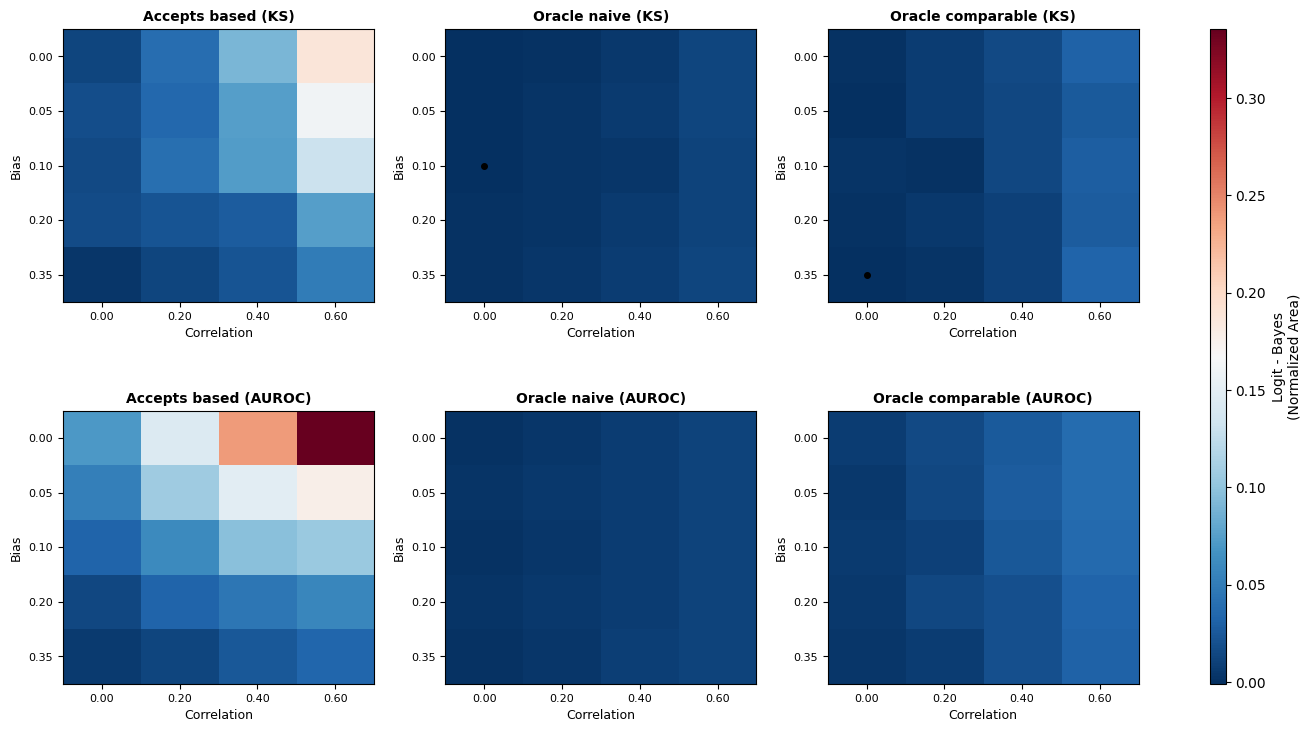

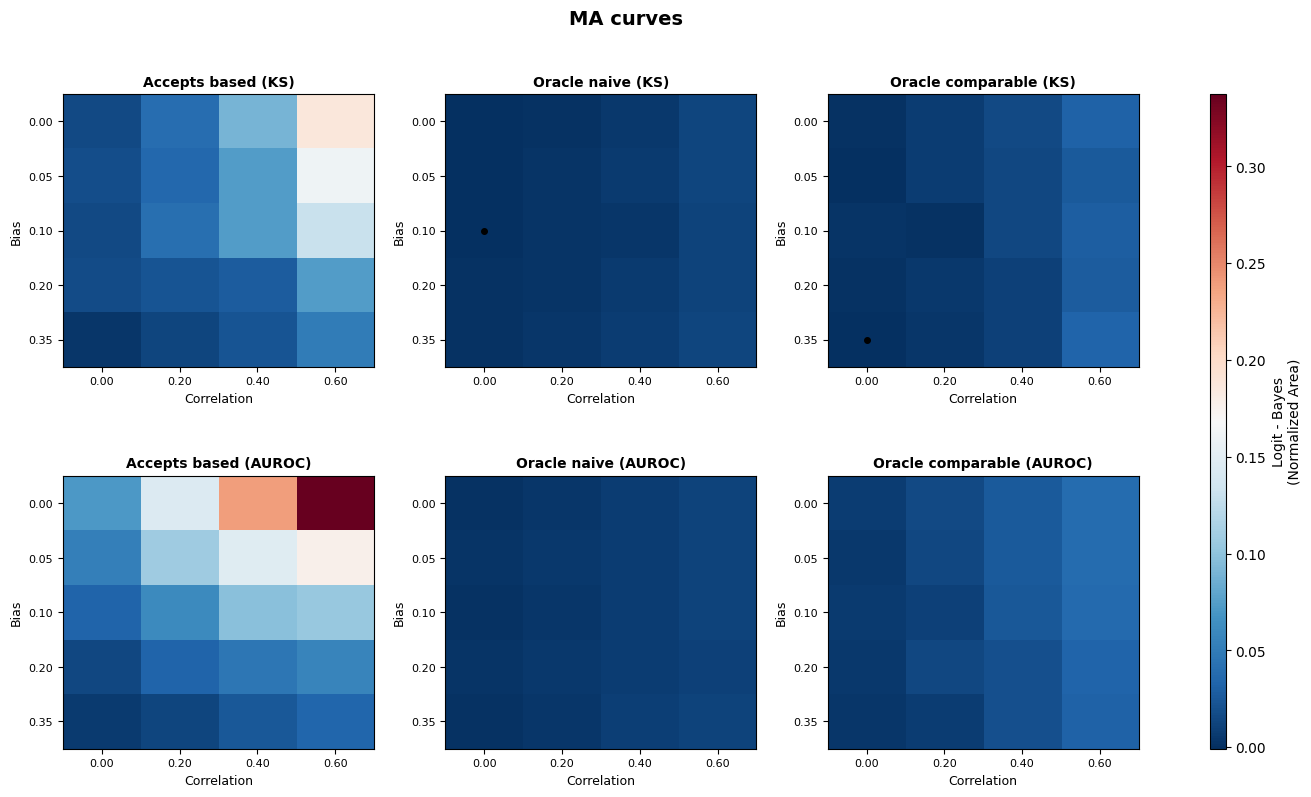

In [ ]:
diff_types = ["diffs", "ma_diffs"]
# Construct all_diffs tensor
## [B, Co, E, M, Cl, D, N], [N]
all_diffs_new, sample_sizes, B, Co, E, M, D = construct_all_diffs_tensor(
    all_sim_objs,
    biases=grid_biases,
    corrs=grid_corrs,
    expectation_types=EXPECTATION_TYPES,
    metric_categories=METRIC_CATEGORIES,
    diff_types=diff_types,
    classifiers=["logit", "bayes"]
)

# Get areas
areas = get_areas(all_diffs_new, sample_sizes)

# Normalize areas
normed_areas = normalize_areas(areas, METRIC_CATEGORIES, sample_sizes) # [B, Co, E, M, Cl, D]

# # Compute logit - bayes difference
logit_area_minus_bayes_normed = normed_areas[..., 0, :] - normed_areas[..., 1, :] # [B, Co, E, M, D]


def custom_title_mapping(e_type: str, m_cat: str) -> str:
    e_type_map = {
        "acc_based" : "Accepts based",
        "oracle_naive" : "Oracle naive",
        "oracle_comparable" : "Oracle comparable"
    }
    m_cat_mapper = {
        "roc" : "AUROC",
        "ks" : "KS"
    }
    return f'{e_type_map[e_type]} ({m_cat_mapper[m_cat]})'

idx_diffs = 0

plot_heatmap_grid(
    data=logit_area_minus_bayes_normed[..., idx_diffs],
    metric_categories=METRIC_CATEGORIES,
    expectation_types=EXPECTATION_TYPES,
    biases=grid_biases,
    corrs=grid_corrs,
    cmap='RdBu_r',
    suptitle='',
    title_bold=True,
    cbar_label='Logit - Bayes\n(Normalized Area)',
    title_mapping=custom_title_mapping
)

plot_heatmap_grid(
    data=logit_area_minus_bayes_normed[..., 1],
    metric_categories=METRIC_CATEGORIES,
    expectation_types=EXPECTATION_TYPES,
    biases=grid_biases,
    corrs=grid_corrs,
    cmap='RdBu_r',
    suptitle="MA curves",
    title_bold=True,
    cbar_label='Logit - Bayes\n(Normalized Area)',
    title_mapping=custom_title_mapping
)

In [ ]:
logit_area_minus_bayes_normed.shape

torch.Size([5, 4, 3, 2, 2])

In [60]:
from typing import Dict, Callable, Optional

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle
from matplotlib.colors import Normalize
from typing import Iterable


def plot_heatmap_grid_multiD(
    data: torch.Tensor,
    metric_categories: list,
    expectation_types: list,
    biases: Dict[str, float],
    corrs: Dict[str, float],
    cmap: str = "RdBu_r",
    suptitle: Optional[str] = None,
    title_bold: bool = True,
    cbar_label: str = "Logit - Bayes\n(Normalized Area)",
    title_mapping: Optional[Callable[[str, str], str]] = None,
    d_lbls: Optional[Iterable[str]] = None
) -> None:
    """
    data has shape

        [Bias, Corr, Expectation, Metric, D]

    Every heatmap cell is split horizontally into D equal pieces.
    """

    M_len = len(metric_categories)
    E_len = len(expectation_types)

    # ------------------------------------------------------------------
    # ordering
    # ------------------------------------------------------------------

    sorted_bias_keys = sorted(biases.keys(), key=lambda x: biases[x])
    sorted_corr_keys = sorted(corrs.keys(), key=lambda x: corrs[x])

    bias_key_list = list(biases.keys())
    corr_key_list = list(corrs.keys())

    sorted_bias_idxs = [bias_key_list.index(k) for k in sorted_bias_keys]
    sorted_corr_idxs = [corr_key_list.index(k) for k in sorted_corr_keys]

    bias_labels = [f"{biases[k]:.2f}" for k in sorted_bias_keys]
    corr_labels = [f"{corrs[k]:.2f}" for k in sorted_corr_keys]

    # ------------------------------------------------------------------
    # figure
    # ------------------------------------------------------------------

    fig = plt.figure(figsize=(5 * E_len, 4 * M_len + 0.5))
    D = data.shape[-1]

    d_lbls_is_not_none = d_lbls is not None
    if d_lbls_is_not_none:
        assert len(d_lbls) == D
    gs = gridspec.GridSpec(
        M_len + int(d_lbls_is_not_none),
        E_len + 1,
        figure=fig,
        width_ratios=[1] * E_len + [0.05],
        height_ratios= [1] * M_len + [0.05] * int(d_lbls_is_not_none),
        wspace=0.3,
        hspace=0.4,
    )

    data_np = data.numpy() # [B, Co, E, M, D]

    vmin = data_np.min()
    vmax = data_np.max()

    cmap_obj = plt.get_cmap(cmap)
    norm = Normalize(vmin=vmin, vmax=vmax)

    

    # ------------------------------------------------------------------
    # draw all heatmaps
    # ------------------------------------------------------------------

    for m_idx, m_cat in enumerate(metric_categories):

        for e_idx, e_type in enumerate(expectation_types):

            ax = fig.add_subplot(gs[m_idx, e_idx])

            heatmap_data = data_np[:, :, e_idx, m_idx, :] # [B, Co, D]
            heatmap_data = heatmap_data[
                np.ix_(sorted_bias_idxs, sorted_corr_idxs, np.arange(D))
            ]

            n_bias, n_corr, _ = heatmap_data.shape

            width = 1.0 / D

            for i in range(n_bias):
                for j in range(n_corr):

                    for d in range(D):

                        value = heatmap_data[i, j, d]

                        rect = Rectangle(
                            (j - 0.5 + d * width, i - 0.5),
                            width,
                            1,
                            facecolor=cmap_obj(norm(value)),
                            edgecolor="none",
                        )

                        ax.add_patch(rect)

                        if value < 0:
                            ax.plot(
                                j - 0.5 + (d + 0.5) * width,
                                i,
                                "k.",
                                markersize=5,
                            )

            # draw grid
            for x in range(n_corr + 1):
                ax.axvline(x - 0.5, color="black", lw=0.8)

            for y in range(n_bias + 1):
                ax.axhline(y - 0.5, color="black", lw=0.8)

            # optional separators between D pieces
            if D > 1:
                for x in range(n_corr):
                    for d in range(1, D):
                        ax.axvline(x=x - 0.5 + d * width, ymin = -0.5, ymax=n_bias - 0.5,
                                   color='k', alpha=.5, lw=0.5, ls="--")

            ax.set_xlim(-0.5, n_corr - 0.5)
            ax.set_ylim(n_bias - 0.5, -0.5)

            ax.set_xticks(range(n_corr))
            ax.set_xticklabels(corr_labels, fontsize=8)

            ax.set_yticks(range(n_bias))
            ax.set_yticklabels(bias_labels, fontsize=8)

            ax.set_xlabel("Correlation", fontsize=9)
            ax.set_ylabel("Bias", fontsize=9)

            if title_mapping is None:
                title = f"{e_type}_{m_cat}"
            else:
                title = title_mapping(e_type, m_cat)

            ax.set_title(
                title,
                fontsize=10,
                fontweight="bold" if title_bold else "normal",
            )

    # ------------------------------------------------------------------
    # colorbar
    # ------------------------------------------------------------------

    cbar_ax = fig.add_subplot(gs[:, E_len])

    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap_obj)
    sm.set_array([])

    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_label(cbar_label)

    if suptitle:
        fig.suptitle(
            suptitle,
            fontsize=14,
            fontweight="bold",
            y=0.98,
        )

    if d_lbls_is_not_none:
        ax = fig.add_subplot(gs[-1, :])
        diffs_as_str = "".join([l + (', ' if i < D-2 else " and " if i == D-2 else "") for i, l in enumerate(d_lbls)])
        ax.axis('off')
        ax.text(
            y=0, x=0,
            s = (
                "Each subplot shows the data acoording to differences of " +
                diffs_as_str
            )
        )


    plt.show()


In [ ]:
from thesis.helper_scripts.hypothesis_visualization import construct_all_diffs_tensor
from thesis.helper_scripts.general import extract_all_sim_objs, extract_biases_and_corrs_from_dirnames

grid_biases, grid_corrs = extract_biases_and_corrs_from_dirnames(grid_path)
all_sim_objs = extract_all_sim_objs(grid_path, grid_biases, grid_corrs)

diff_types = ["diffs", "ma_diffs"]
# Construct all_diffs tensor
## [B, Co, E, M, Cl, D, N], [N]
all_diffs_new, sample_sizes, B, Co, E, M, D = construct_all_diffs_tensor(
    all_sim_objs,
    biases=grid_biases,
    corrs=grid_corrs,
    expectation_types=EXPECTATION_TYPES,
    metric_categories=METRIC_CATEGORIES,
    diff_types=diff_types,
    classifiers=["logit", "bayes"]
)
# Get areas
areas = get_areas(all_diffs_new, sample_sizes)

# Normalize areas
normed_areas = normalize_areas(areas, ~all_diffs_new.isnan(), sample_sizes) # [B, Co, E, M, Cl, D]

# # Compute logit - bayes difference
logit_area_minus_bayes_normed = normed_areas[..., 0, :] - normed_areas[..., 1, :] # [B, Co, E, M, D]

TypeError: must be real number, not dict_values

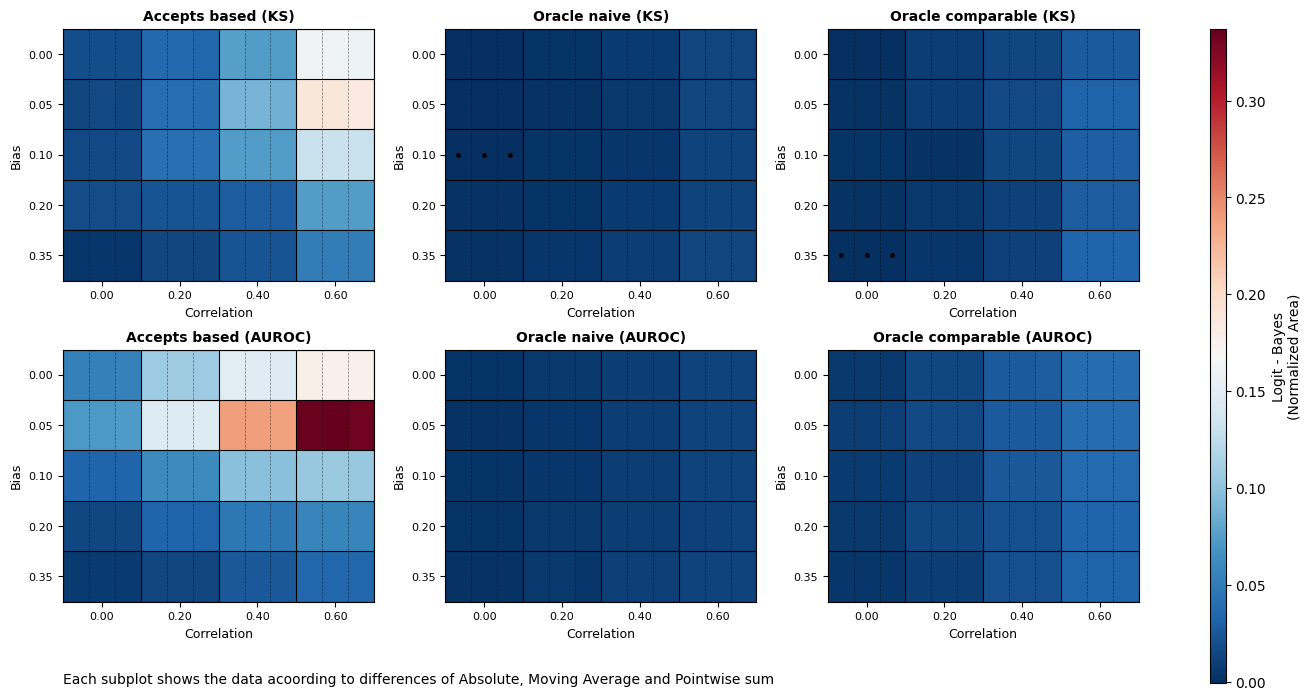

In [ ]:
def custom_title_mapping(e_type: str, m_cat: str) -> str:
    e_type_map = {
        "acc_based" : "Accepts based",
        "oracle_naive" : "Oracle naive",
        "oracle_comparable" : "Oracle comparable"
    }
    m_cat_mapper = {
        "roc" : "AUROC",
        "ks" : "KS"
    }
    return f'{e_type_map[e_type]} ({m_cat_mapper[m_cat]})'

plot_heatmap_grid_multiD(
    data=logit_area_minus_bayes_normed,
    metric_categories=METRIC_CATEGORIES,
    expectation_types=EXPECTATION_TYPES,
    biases=grid_biases,
    corrs=grid_corrs,
    cmap="RdBu_r",
    suptitle="",
    title_bold=True,
    cbar_label="Logit - Bayes\n(Normalized Area)",
    title_mapping=custom_title_mapping,
    d_lbls=["Absolute", "Moving Average", "Pointwise sum"]
)

In [ ]:
logit_area_minus_bayes_normed[:, :, 0, 0, :].movedim(-1,0)

tensor([[[0.0180, 0.0355, 0.0745, 0.1612],
         [0.0133, 0.0388, 0.0901, 0.1875],
         [0.0158, 0.0408, 0.0736, 0.1306],
         [0.0171, 0.0228, 0.0280, 0.0741],
         [0.0043, 0.0132, 0.0223, 0.0497]],

        [[0.0181, 0.0352, 0.0739, 0.1608],
         [0.0152, 0.0400, 0.0900, 0.1878],
         [0.0157, 0.0405, 0.0735, 0.1305],
         [0.0171, 0.0227, 0.0279, 0.0740],
         [0.0042, 0.0132, 0.0224, 0.0497]],

        [[0.0185, 0.0346, 0.0736, 0.1584],
         [0.0139, 0.0380, 0.0871, 0.1830],
         [0.0159, 0.0406, 0.0733, 0.1301],
         [0.0170, 0.0225, 0.0277, 0.0739],
         [0.0042, 0.0132, 0.0225, 0.0498]]], dtype=torch.float64)

In [ ]:
from thesis.helper_scripts.hypothesis_visualization import construct_all_diffs_tensor
from thesis.helper_scripts.general import extract_all_sim_objs, extract_biases_and_corrs_from_dirnames

grid_biases, grid_corrs = extract_biases_and_corrs_from_dirnames(grid_path)
grid_biases = dict(sorted(grid_biases.items(), key=lambda x: x[1]))
grid_corrs = dict(sorted(grid_corrs.items(), key=lambda x: x[1]))
all_sim_objs = extract_all_sim_objs(grid_path, grid_biases, grid_corrs)

diff_types = ["diffs", "ma_diffs"]
# Construct all_diffs tensor
## [B, Co, E, M, Cl, D, N], [N]
all_diffs_new, sample_sizes, B, Co, E, M, D = construct_all_diffs_tensor(
    all_sim_objs,
    biases=grid_biases,
    corrs=grid_corrs,
    expectation_types=EXPECTATION_TYPES,
    metric_categories=METRIC_CATEGORIES,
    diff_types=diff_types,
    classifiers=["logit", "bayes"]
)
# Get areas
areas = get_areas(all_diffs_new, sample_sizes)

# Normalize areas
normed_areas = normalize_areas(areas, ~all_diffs_new.isnan(), sample_sizes) # [B, Co, E, M, Cl, D]

# # Compute logit - bayes difference
logit_area_minus_bayes_normed = normed_areas[..., 0, :] - normed_areas[..., 1, :] # [B, Co, E, M, D]

In [ ]:
logit_area_minus_bayes_normed.shape

torch.Size([5, 4, 3, 2, 3])

[[[0.01798458 0.01807072 0.01851671]
  [0.03550423 0.03518155 0.03460631]
  [0.07448646 0.07386279 0.07358365]
  [0.16115028 0.16078019 0.15839993]]

 [[0.01332006 0.0152444  0.01386102]
  [0.03880945 0.04004251 0.03802443]
  [0.09008943 0.09004445 0.08710492]
  [0.18747992 0.18776243 0.18304909]]

 [[0.0158209  0.01574368 0.01586409]
  [0.04077585 0.04054471 0.04059024]
  [0.07361296 0.07349852 0.07331883]
  [0.13055052 0.13045325 0.13008628]]

 [[0.01708245 0.01705817 0.01698729]
  [0.02281861 0.02272634 0.02253586]
  [0.02796147 0.02786204 0.02771628]
  [0.07409071 0.07403691 0.07392963]]

 [[0.00432507 0.00423378 0.00415634]
  [0.01322948 0.01320861 0.01315844]
  [0.02233475 0.02236775 0.02245768]
  [0.04971037 0.04972281 0.04984347]]]
[[[ 0.00017249  0.00017178  0.00017793]
  [ 0.00197612  0.00197194  0.00198983]
  [ 0.00644545  0.00646053  0.00643296]
  [ 0.01275279  0.01277343  0.0127742 ]]

 [[ 0.00013284  0.00013943  0.00013349]
  [ 0.00151741  0.00151733  0.00152586]
  [ 0.00

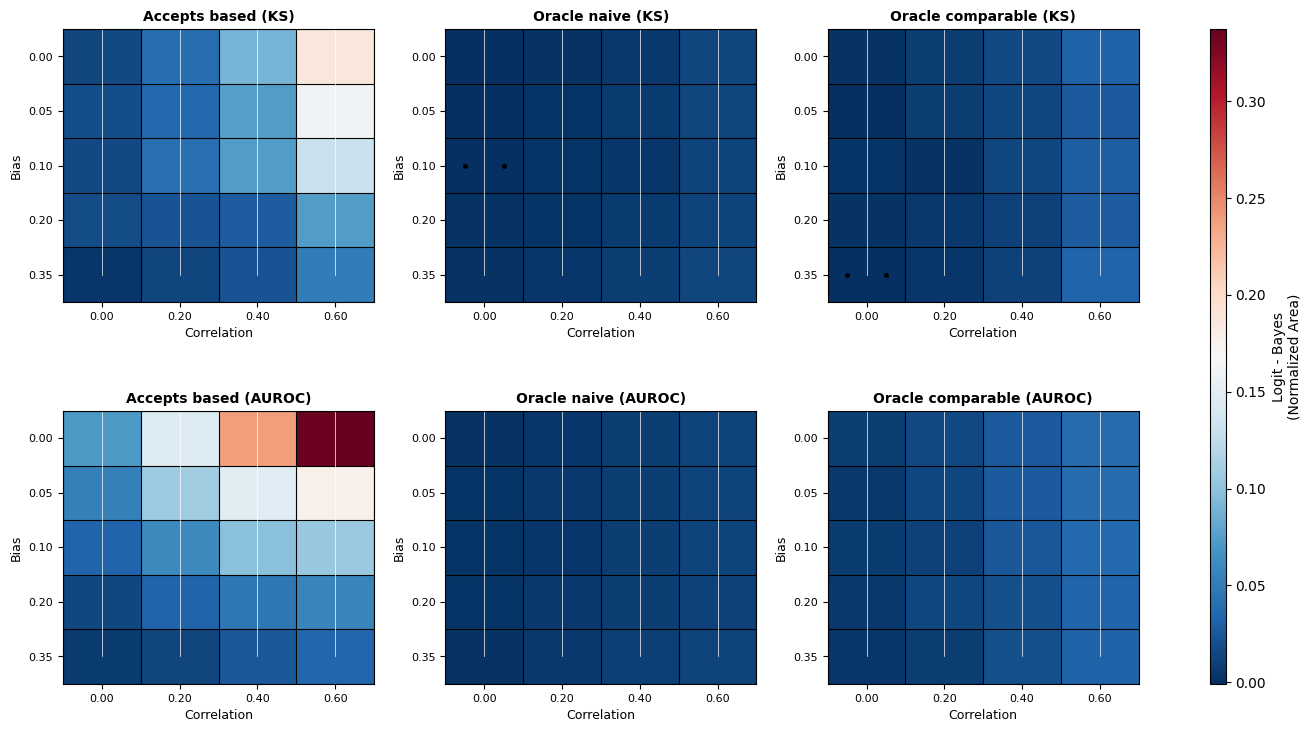

In [ ]:
def custom_title_mapping(e_type: str, m_cat: str) -> str:
    e_type_map = {
        "acc_based" : "Accepts based",
        "oracle_naive" : "Oracle naive",
        "oracle_comparable" : "Oracle comparable"
    }
    m_cat_mapper = {
        "roc" : "AUROC",
        "ks" : "KS"
    }
    return f'{e_type_map[e_type]} ({m_cat_mapper[m_cat]})'

plot_heatmap_grid_multiD(
    data=logit_area_minus_bayes_normed,
    metric_categories=METRIC_CATEGORIES,
    expectation_types=EXPECTATION_TYPES,
    biases=grid_biases,
    corrs=grid_corrs,
    cmap="RdBu_r",
    suptitle="",
    title_bold=True,
    cbar_label="Logit - Bayes\n(Normalized Area)",
    title_mapping=custom_title_mapping,
)

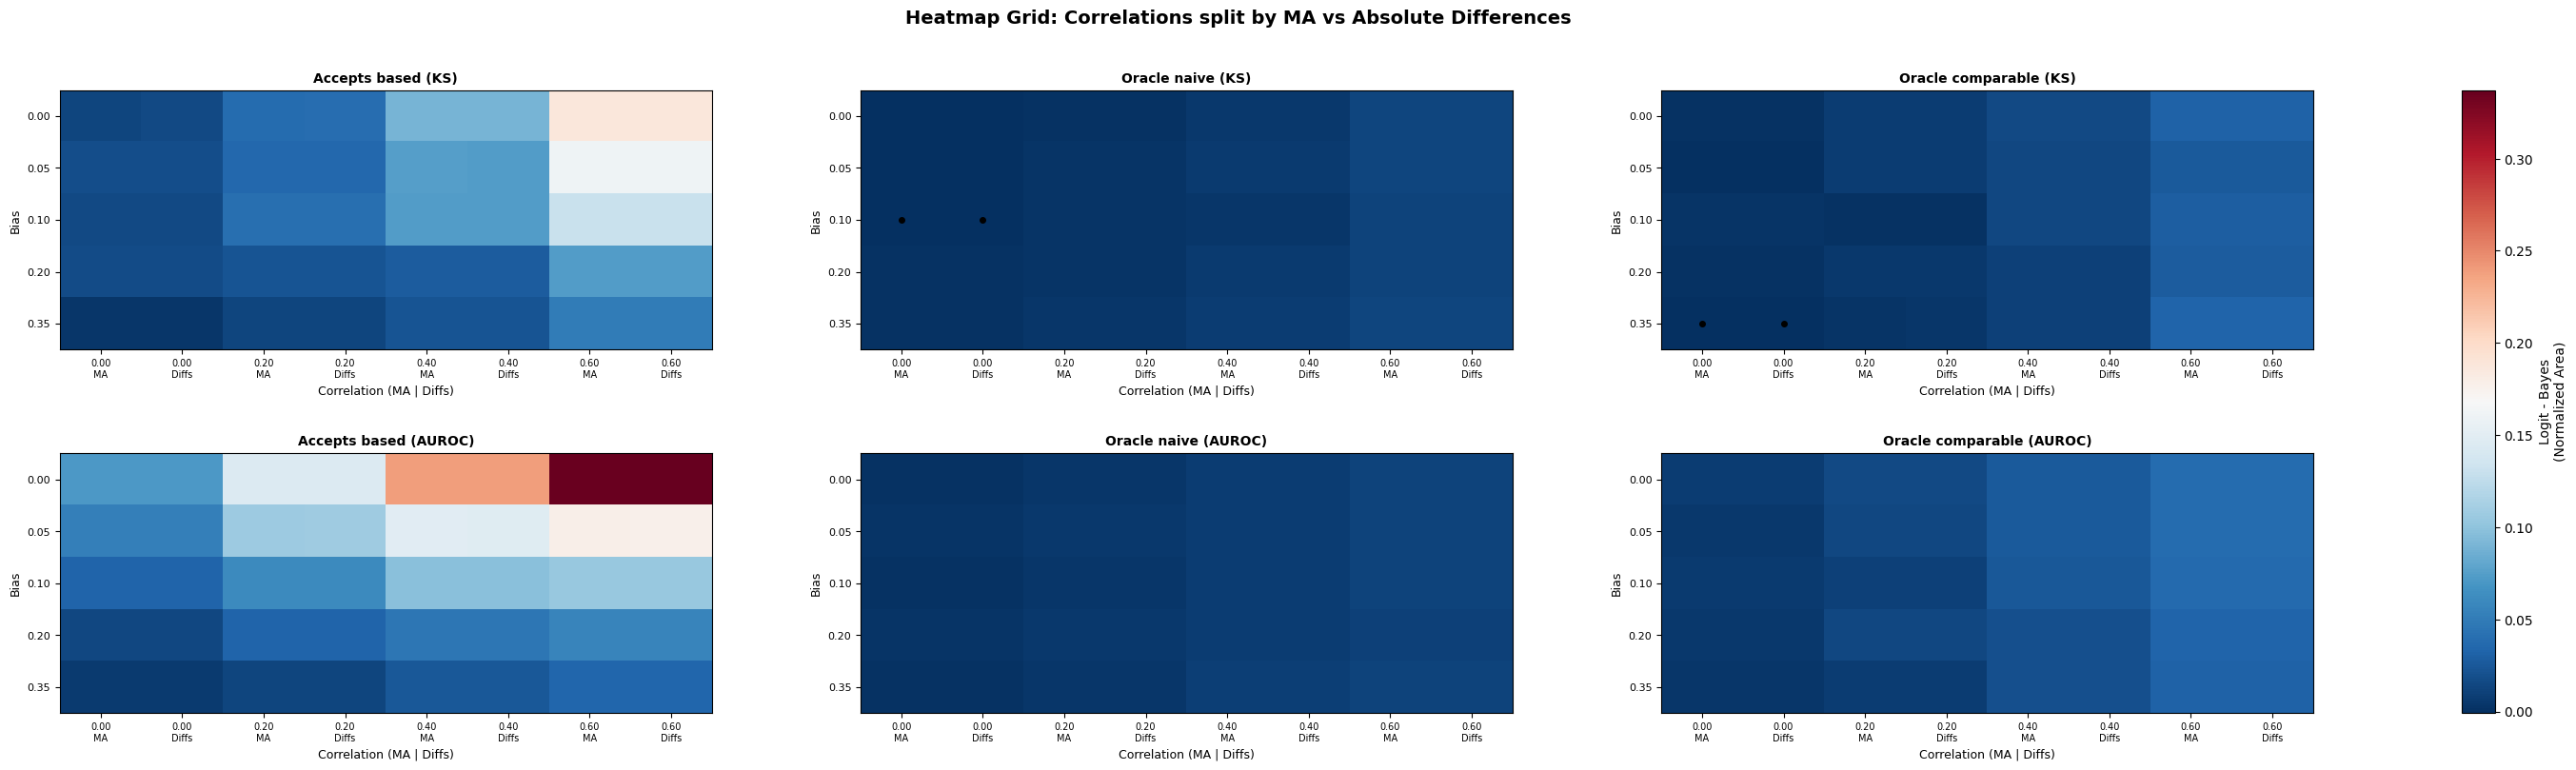

In [ ]:
# === TEST: Heatmap grid with diff types on x-axis ===
# Test the plot_heatmap_grid_with_diff_types function
# Each heatmap has: y-axis = biases, x-axis = correlations split by diff types (MA | Diffs pairs)

plot_heatmap_grid_with_diff_types(
    data=logit_area_minus_bayes_normed,
    metric_categories=METRIC_CATEGORIES,
    expectation_types=EXPECTATION_TYPES,
    biases=grid_biases,
    corrs=grid_corrs,
    diff_labels=['MA', 'Diffs'],
    cmap='RdBu_r',
    suptitle='Heatmap Grid: Correlations split by MA vs Absolute Differences',
    title_bold=True,
    cbar_label='Logit - Bayes\n(Normalized Area)',
    title_mapping=custom_title_mapping
)

Plotting MA and Diffs SEPARATELY with independent color scales...



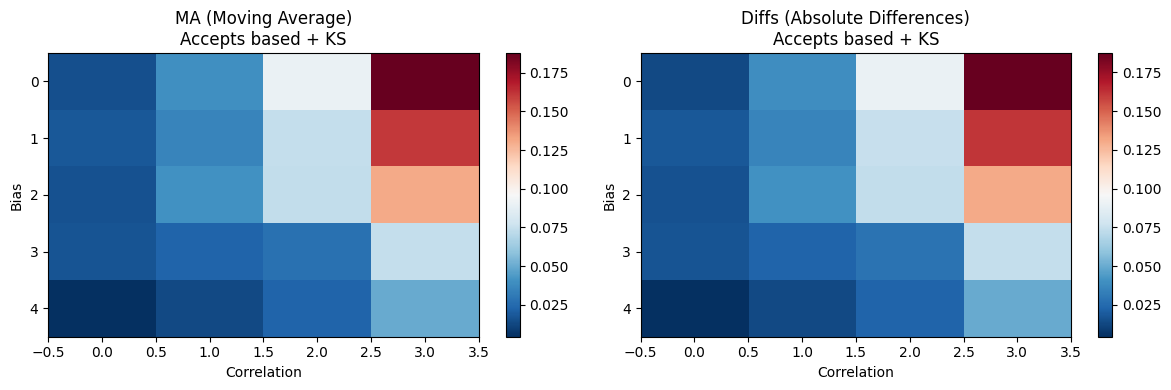


If these two plots look different in color patterns, the issue is that
the unified color scale in the main plot is too narrow to show the differences.
MA range: [0.004234, 0.187762]
Diffs range: [0.004325, 0.187480]


In [ ]:
# === VISUAL COMPARISON: Plot MA and Diffs separately with independent color scaling ===

# Extract data separately with independent min/max for each
data_ma_full = logit_area_minus_bayes_normed[..., 1]  # [B, Co, E, M]
data_diffs_full = logit_area_minus_bayes_normed[..., 0]  # [B, Co, E, M]

print("Plotting MA and Diffs SEPARATELY with independent color scales...")
print()

# Create two subplots side-by-side for one example: Accepts based + KS
fig, (ax_ma, ax_diffs) = plt.subplots(1, 2, figsize=(12, 4))

# Sort indices for consistent ordering
sorted_bias_keys = sorted(grid_biases.keys(), key=lambda x: grid_biases[x])
sorted_corr_keys = sorted(grid_corrs.keys(), key=lambda x: grid_corrs[x])
bias_key_list = list(grid_biases.keys())
corr_key_list = list(grid_corrs.keys())
sorted_bias_idxs = [bias_key_list.index(k) for k in sorted_bias_keys]
sorted_corr_idxs = [corr_key_list.index(k) for k in sorted_corr_keys]

# MA plot
e_idx, m_idx = 0, 0
ma_data = data_ma_full[:, :, e_idx, m_idx].numpy()
ma_reordered = ma_data[np.ix_(sorted_bias_idxs, sorted_corr_idxs)]
im_ma = ax_ma.imshow(ma_reordered, cmap='RdBu_r', aspect='auto')
ax_ma.set_title(f'MA (Moving Average)\nAccepts based + KS')
ax_ma.set_xlabel('Correlation')
ax_ma.set_ylabel('Bias')
plt.colorbar(im_ma, ax=ax_ma)

# Diffs plot
diffs_data = data_diffs_full[:, :, e_idx, m_idx].numpy()
diffs_reordered = diffs_data[np.ix_(sorted_bias_idxs, sorted_corr_idxs)]
im_diffs = ax_diffs.imshow(diffs_reordered, cmap='RdBu_r', aspect='auto')
ax_diffs.set_title(f'Diffs (Absolute Differences)\nAccepts based + KS')
ax_diffs.set_xlabel('Correlation')
ax_diffs.set_ylabel('Bias')
plt.colorbar(im_diffs, ax=ax_diffs)

plt.tight_layout()
plt.show()

print()
print("If these two plots look different in color patterns, the issue is that")
print("the unified color scale in the main plot is too narrow to show the differences.")
print(f"MA range: [{ma_reordered.min():.6f}, {ma_reordered.max():.6f}]")
print(f"Diffs range: [{diffs_reordered.min():.6f}, {diffs_reordered.max():.6f}]")

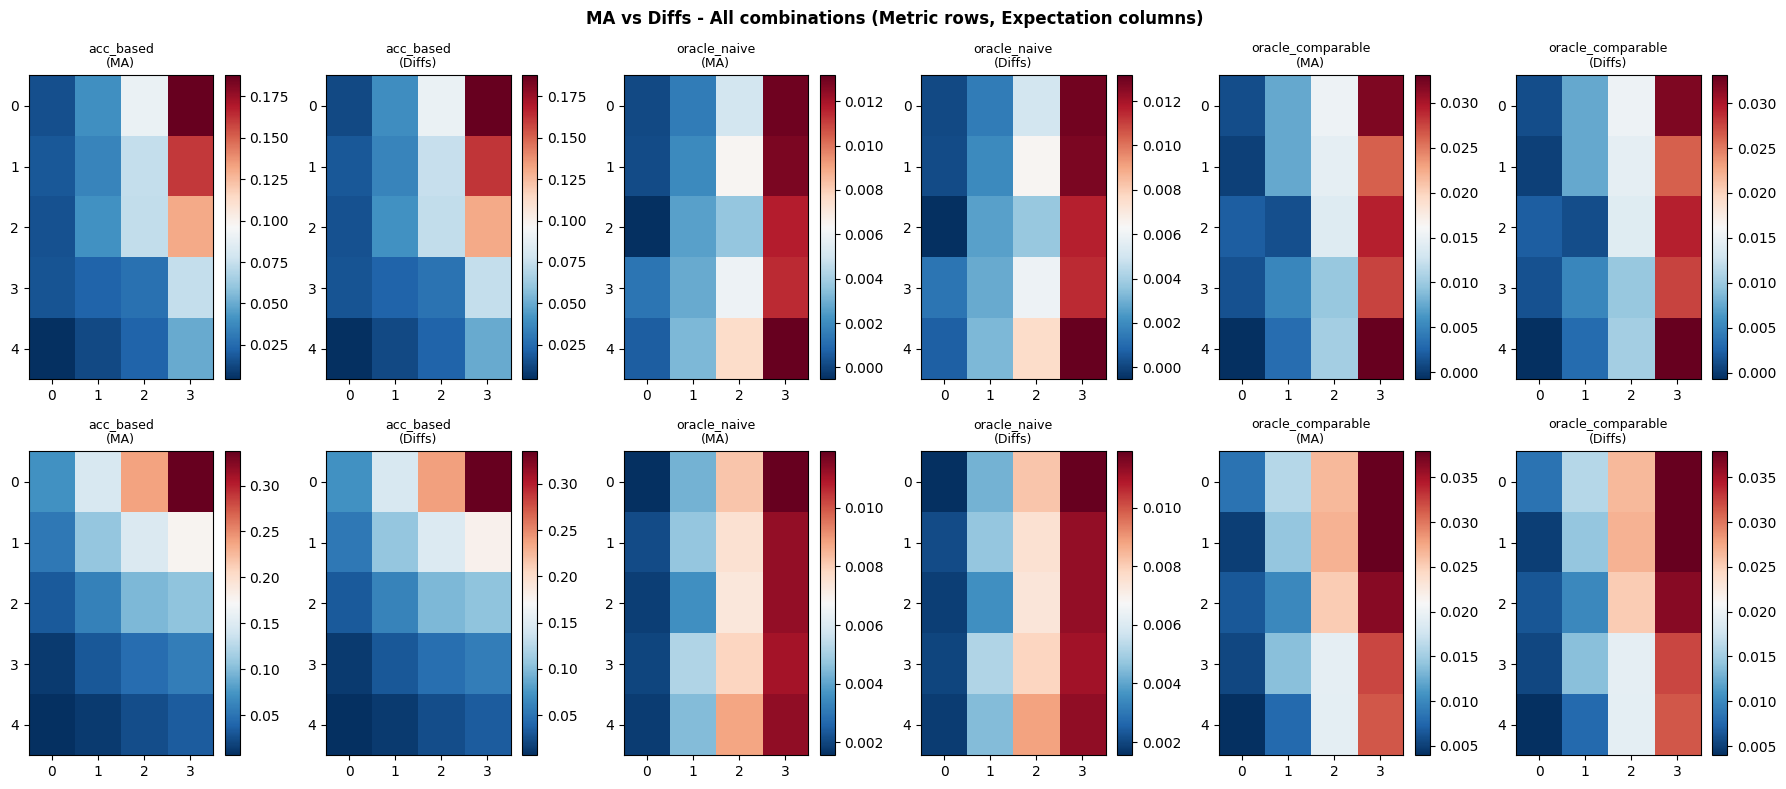

Compare the MA and Diffs columns:
- If they look visually identical, the data values are too similar
- If they look different, we might need independent color scales per column


In [ ]:
# === FULL COMPARISON: Plot all 6 heatmaps (MA vs Diffs) separately ===

data_ma_full = logit_area_minus_bayes_normed[..., 1]  # [B, Co, E, M]
data_diffs_full = logit_area_minus_bayes_normed[..., 0]  # [B, Co, E, M]

fig, axes = plt.subplots(2, 6, figsize=(18, 8))

for m_idx, m_cat in enumerate(METRIC_CATEGORIES):
    for e_idx, e_type in enumerate(EXPECTATION_TYPES):
        # MA heatmap
        ax_ma = axes[m_idx, e_idx * 2]
        ma_data = data_ma_full[:, :, e_idx, m_idx].numpy()
        ma_reordered = ma_data[np.ix_(sorted_bias_idxs, sorted_corr_idxs)]
        im_ma = ax_ma.imshow(ma_reordered, cmap='RdBu_r', aspect='auto')
        ax_ma.set_title(f'{e_type}\n(MA)', fontsize=9)
        plt.colorbar(im_ma, ax=ax_ma)
        
        # Diffs heatmap
        ax_diffs = axes[m_idx, e_idx * 2 + 1]
        diffs_data = data_diffs_full[:, :, e_idx, m_idx].numpy()
        diffs_reordered = diffs_data[np.ix_(sorted_bias_idxs, sorted_corr_idxs)]
        im_diffs = ax_diffs.imshow(diffs_reordered, cmap='RdBu_r', aspect='auto')
        ax_diffs.set_title(f'{e_type}\n(Diffs)', fontsize=9)
        plt.colorbar(im_diffs, ax=ax_diffs)

plt.suptitle('MA vs Diffs - All combinations (Metric rows, Expectation columns)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("Compare the MA and Diffs columns:")
print("- If they look visually identical, the data values are too similar")
print("- If they look different, we might need independent color scales per column")

=== Checking alternative data sources ===

areas_new shape: torch.Size([5, 4, 3, 2, 2, 2])
logit_area_minus_bayes_normed_new shape: torch.Size([5, 4, 3, 2, 2])

=== Pre-normalized areas (raw, not normalized) ===
Logit MA - Min: 1676.827628, Max: 65298.061568, Mean: 15425.355630
Logit Diffs - Min: 1675.688484, Max: 65151.948664, Mean: 15416.581770

=== Logit minus Bayes (pre-normalized) ===
MA - Min: -233.145206, Max: 56140.965075, Mean: 6516.785298
Diffs - Min: -224.503673, Max: 56056.496602, Mean: 6512.790140



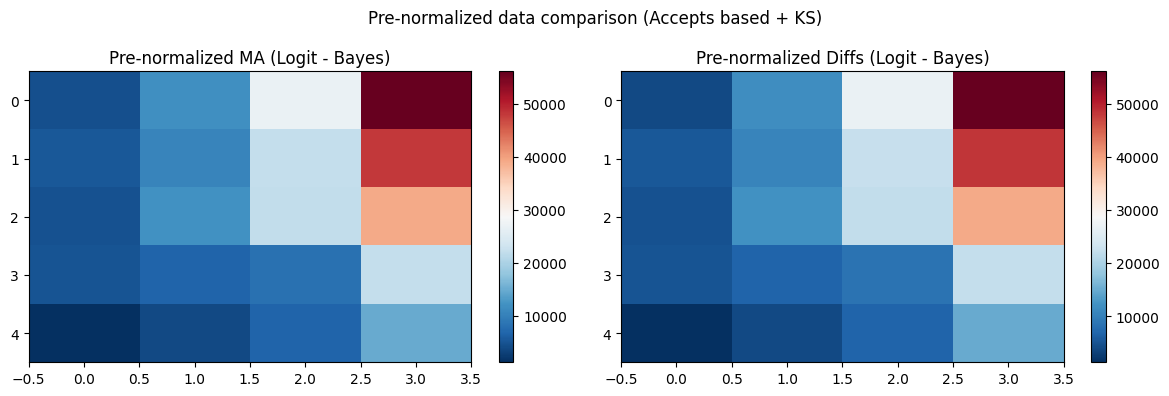

Do the pre-normalized plots show clearer visual differences?
Pre-norm MA range: [1265.900336, 56140.965075]
Pre-norm Diffs range: [1293.194958, 56056.496602]


In [ ]:
# === COMPARISON: Check if maybe we should use areas_new instead ===
# Perhaps the visual differences are more apparent in the pre-normalized data

print("=== Checking alternative data sources ===")
print()
print(f"areas_new shape: {areas.shape}")
print(f"logit_area_minus_bayes_normed_new shape: {logit_area_minus_bayes_normed.shape}")
print()

# areas_new has shape [B, Co, E, M, Cl, D]
# Cl: 0=logit, 1=bayes
# D: 0=diffs, 1=ma_diffs

areas_ma_logit = areas[..., 0, 1]  # [B, Co, E, M] - Logit, MA
areas_diffs_logit = areas[..., 0, 0]  # [B, Co, E, M] - Logit, Diffs
areas_ma_bayes = areas[..., 1, 1]  # [B, Co, E, M] - Bayes, MA
areas_diffs_bayes = areas[..., 1, 0]  # [B, Co, E, M] - Bayes, Diffs

print("=== Pre-normalized areas (raw, not normalized) ===")
print(f"Logit MA - Min: {areas_ma_logit.min():.6f}, Max: {areas_ma_logit.max():.6f}, Mean: {areas_ma_logit.mean():.6f}")
print(f"Logit Diffs - Min: {areas_diffs_logit.min():.6f}, Max: {areas_diffs_logit.max():.6f}, Mean: {areas_diffs_logit.mean():.6f}")
print()

# Logit - Bayes difference (pre-normalized)
diff_ma = areas_ma_logit - areas_ma_bayes
diff_diffs = areas_diffs_logit - areas_diffs_bayes

print("=== Logit minus Bayes (pre-normalized) ===")
print(f"MA - Min: {diff_ma.min():.6f}, Max: {diff_ma.max():.6f}, Mean: {diff_ma.mean():.6f}")
print(f"Diffs - Min: {diff_diffs.min():.6f}, Max: {diff_diffs.max():.6f}, Mean: {diff_diffs.mean():.6f}")
print()

# Plot pre-normalized data side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

e_idx, m_idx = 0, 0
ma_pre = diff_ma[:, :, e_idx, m_idx].numpy()
ma_pre_reordered = ma_pre[np.ix_(sorted_bias_idxs, sorted_corr_idxs)]

diffs_pre = diff_diffs[:, :, e_idx, m_idx].numpy()
diffs_pre_reordered = diffs_pre[np.ix_(sorted_bias_idxs, sorted_corr_idxs)]

im_ma = axes[0].imshow(ma_pre_reordered, cmap='RdBu_r', aspect='auto')
axes[0].set_title('Pre-normalized MA (Logit - Bayes)')
plt.colorbar(im_ma, ax=axes[0])

im_diffs = axes[1].imshow(diffs_pre_reordered, cmap='RdBu_r', aspect='auto')
axes[1].set_title('Pre-normalized Diffs (Logit - Bayes)')
plt.colorbar(im_diffs, ax=axes[1])

plt.suptitle('Pre-normalized data comparison (Accepts based + KS)')
plt.tight_layout()
plt.show()

print("Do the pre-normalized plots show clearer visual differences?")
print(f"Pre-norm MA range: [{ma_pre_reordered.min():.6f}, {ma_pre_reordered.max():.6f}]")
print(f"Pre-norm Diffs range: [{diffs_pre_reordered.min():.6f}, {diffs_pre_reordered.max():.6f}]")

Testing plot_heatmap_grid_with_diff_types_prenorm with pre-normalized data...



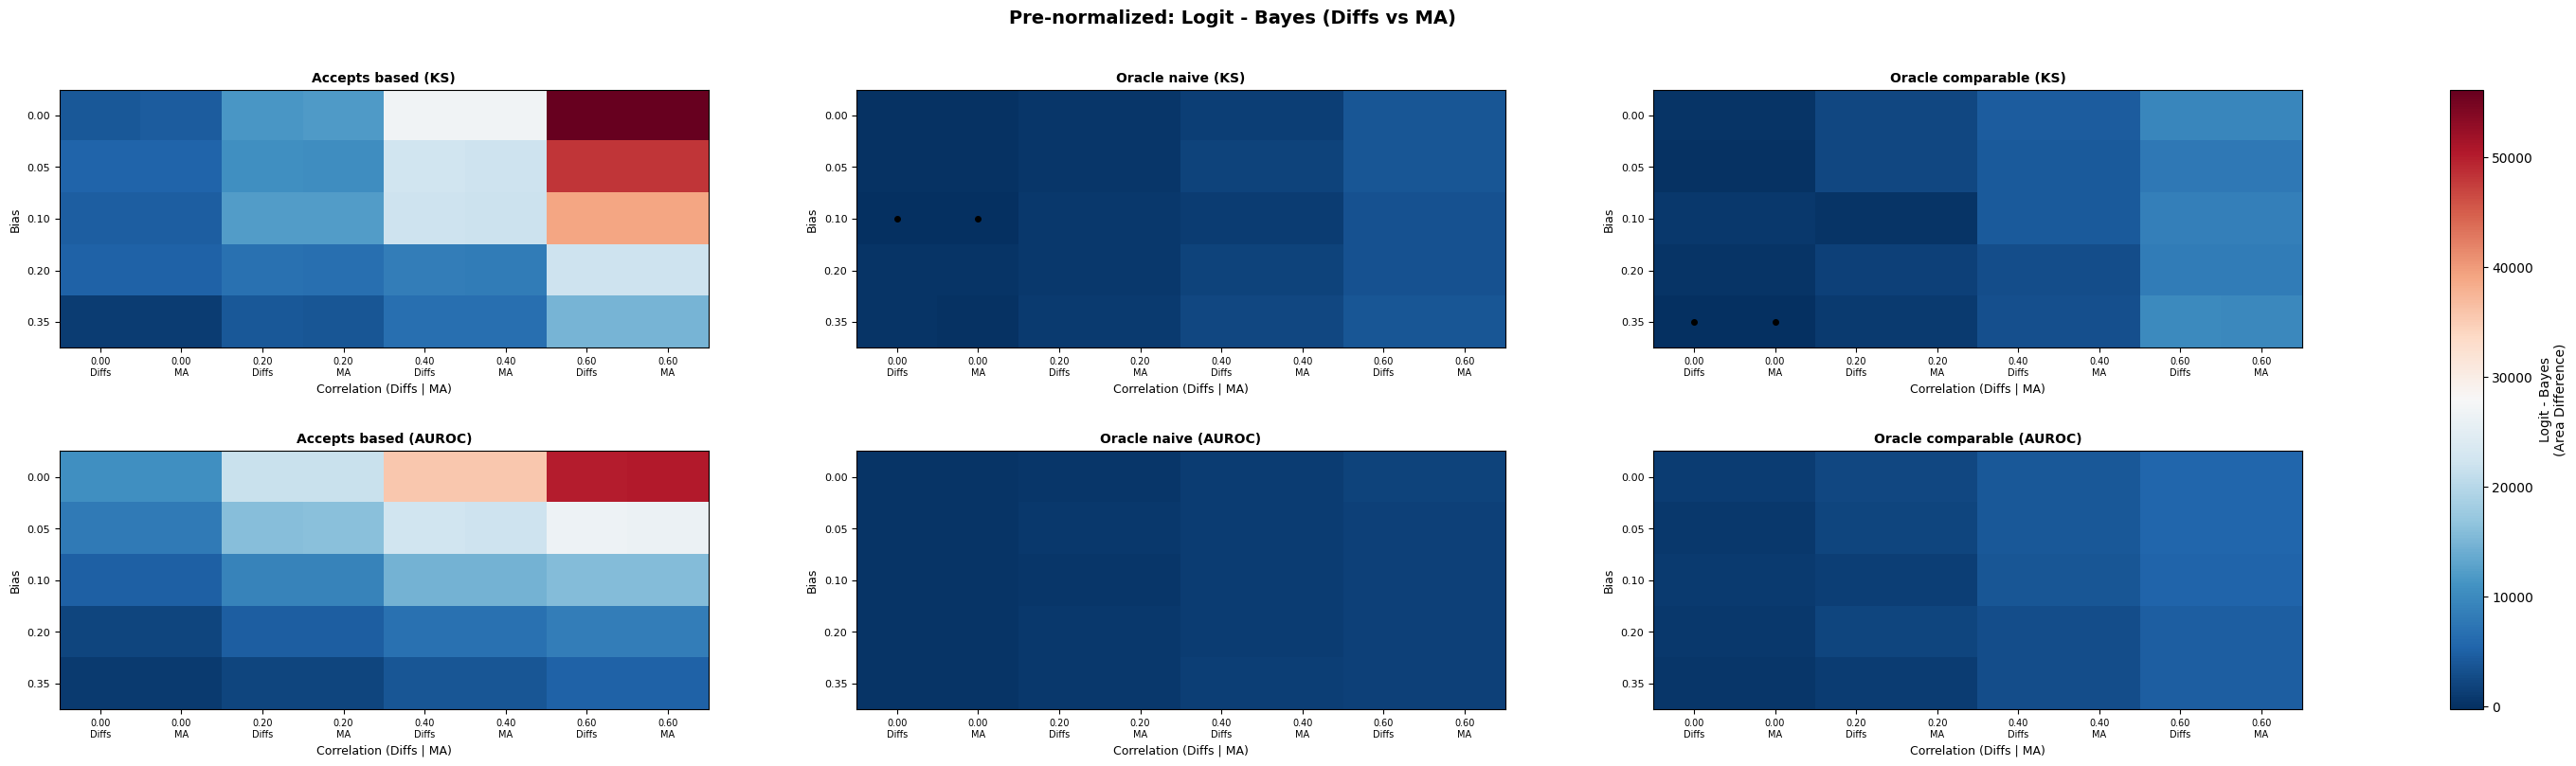

In [ ]:
# === NEW FUNCTION: plot_heatmap_grid_with_diff_types using areas_new (pre-normalized) ===

def plot_heatmap_grid_with_diff_types_prenorm(
    areas: torch.Tensor,  # [B, Co, E, M, Cl, D]
    metric_categories: list,
    expectation_types: list,
    biases: Dict[str, float],
    corrs: Dict[str, float],
    diff_labels: Optional[list] = None,
    cmap: str = 'RdBu_r',
    suptitle: Optional[str] = None,
    title_bold: bool = True,
    cbar_label: str = 'Logit - Bayes\n(Area Difference)',
    title_mapping: Optional[Callable[[str, str], str]] = None
) -> None:
    """
    Create grid of heatmaps using pre-normalized areas_new data.
    Shows Logit - Bayes differences with MA and Diffs split on x-axis.
    
    Args:
        areas: Full tensor [B, Co, E, M, Cl, D] where Cl: 0=logit, 1=bayes; D: 0=diffs, 1=ma_diffs
        metric_categories: List of metric categories
        expectation_types: List of expectation types
        biases: Dictionary of bias values
        corrs: Dictionary of correlation values
        diff_labels: Labels for diff types
        cmap: Colormap
        suptitle: Super title
        title_bold: Bold titles
        cbar_label: Colorbar label
        title_mapping: Custom title mapping callable
    """
    if diff_labels is None:
        diff_labels = ['MA', 'Diffs']
    
    B, Co, E, M_len, Cl, D = areas.shape
    E_len = len(expectation_types)
    
    # Sort biases and correlations
    sorted_bias_keys = sorted(biases.keys(), key=lambda x: biases[x])
    sorted_corr_keys = sorted(corrs.keys(), key=lambda x: corrs[x])
    
    bias_key_list = list(biases.keys())
    corr_key_list = list(corrs.keys())
    sorted_bias_idxs = [bias_key_list.index(k) for k in sorted_bias_keys]
    sorted_corr_idxs = [corr_key_list.index(k) for k in sorted_corr_keys]
    
    # Extract logit and bayes for each diff type, then compute difference
    areas_logit_ma = areas[..., 0, 1]  # [B, Co, E, M]
    areas_bayes_ma = areas[..., 1, 1]  # [B, Co, E, M]
    areas_logit_diffs = areas[..., 0, 0]  # [B, Co, E, M]
    areas_bayes_diffs = areas[..., 1, 0]  # [B, Co, E, M]
    
    diff_ma = areas_logit_ma - areas_bayes_ma
    diff_diffs = areas_logit_diffs - areas_bayes_diffs
    
    # Global min/max
    v_min = min(diff_ma.min().item(), diff_diffs.min().item())
    v_max = max(diff_ma.max().item(), diff_diffs.max().item())
    
    # Labels
    bias_labels = [f'{biases[k]:.2f}' for k in sorted_bias_keys]
    
    # Figure and GridSpec
    fig = plt.figure(figsize=(4 * Co * D + 1, 4 * M_len + 0.5))
    gs = gridspec.GridSpec(
        M_len, E_len + 1,
        figure=fig,
        width_ratios=[1] * E_len + [0.05],
        wspace=0.3,
        hspace=0.4
    )
    
    im = None
    
    # Create heatmaps
    for m_idx, m_cat in enumerate(metric_categories):
        for e_idx, e_type in enumerate(expectation_types):
            ax = fig.add_subplot(gs[m_idx, e_idx])
            
            # Extract and combine MA and Diffs
            ma_data = diff_ma[:, :, e_idx, m_idx].numpy()
            diffs_data = diff_diffs[:, :, e_idx, m_idx].numpy()
            
            # Reorder by sorted indices
            ma_reordered = ma_data[np.ix_(sorted_bias_idxs, sorted_corr_idxs)]
            diffs_reordered = diffs_data[np.ix_(sorted_bias_idxs, sorted_corr_idxs)]
            
            # Reshape to [B, Co*D] by interleaving
            B_size, Co_size = ma_reordered.shape
            heatmap_data = np.zeros((B_size, Co_size * D))
            for c_idx in range(Co_size):
                heatmap_data[:, c_idx * D + 1] = ma_reordered[:, c_idx]  # MA at even index
                heatmap_data[:, c_idx * D + 0] = diffs_reordered[:, c_idx]  # Diffs at odd index
            
            # Plot heatmap
            im = ax.imshow(heatmap_data, cmap=cmap, aspect='auto', vmin=v_min, vmax=v_max)
            
            # Add black dots for negative values
            negative_mask = heatmap_data < 0
            for i in range(B_size):
                for j in range(heatmap_data.shape[1]):
                    if negative_mask[i, j]:
                        ax.plot(j, i, 'k.', markersize=8)
            
            # X-axis labels: show correlation and diff type
            x_labels = []
            x_ticks = []
            for c_idx, corr_key in enumerate(sorted_corr_keys):
                for d_idx, d_label in enumerate(diff_labels):
                    x_labels.append(f'{corrs[corr_key]:.2f}\n{d_label}')
                    x_ticks.append(c_idx * D + d_idx)
            
            ax.set_xticks(x_ticks)
            ax.set_xticklabels(x_labels, fontsize=7)
            
            # Y-axis labels
            ax.set_yticks(range(B_size))
            ax.set_yticklabels(bias_labels, fontsize=8)
            
            # Title
            if title_mapping is not None:
                title = title_mapping(e_type, m_cat)
            else:
                title = f'{e_type}_{m_cat}'
            
            title_weight = 'bold' if title_bold else 'normal'
            ax.set_title(title, fontsize=10, fontweight=title_weight)
            
            # Labels
            ax.set_xlabel('Correlation (Diffs | MA)', fontsize=9)
            ax.set_ylabel('Bias', fontsize=9)
    
    # Add colorbar
    cbar_ax = fig.add_subplot(gs[:, E_len])
    cbar = fig.colorbar(im, cax=cbar_ax)
    cbar.set_label(cbar_label, fontsize=10)
    
    # Super title
    if suptitle and len(suptitle) > 0:
        fig.suptitle(suptitle, fontsize=14, fontweight='bold', y=0.98)
    
    plt.show()

# Test this version
print("Testing plot_heatmap_grid_with_diff_types_prenorm with pre-normalized data...")
print()

plot_heatmap_grid_with_diff_types_prenorm(
    areas=areas,
    metric_categories=METRIC_CATEGORIES,
    expectation_types=EXPECTATION_TYPES,
    biases=grid_biases,
    corrs=grid_corrs,
    diff_labels=['Diffs', 'MA'],
    cmap='RdBu_r',
    suptitle='Pre-normalized: Logit - Bayes (Diffs vs MA)',
    title_bold=True,
    cbar_label='Logit - Bayes\n(Area Difference)',
    title_mapping=custom_title_mapping
)

In [12]:
all_diffs_new.shape

torch.Size([5, 4, 3, 2, 2, 2, 300])

In [ ]:
areas.shape

torch.Size([5, 4, 3, 2, 2, 2])

In [ ]:
def normalize_areas(
    areas: torch.Tensor,
    metric_categories: list,
    mask_valid_points: torch.Tensor ,
    sample_sizes: torch.Tensor
) -> torch.Tensor:
    """
    Normalize areas by worst-case areas for each metric category.
    
    Args:
        areas: Tensor of shape [B, Co, E, M, Cl, D]
        metric_categories: List of metric categories
        sample_sizes: Tensor of sample sizes
        
    Returns:
        Normalized areas tensor of shape [B, Co, E, M, Cl, D]
    """
    B, Co, E, M, Cl, D, N = mask_valid_points.shape
    
    worse_per_cat = {"ks": 1, "roc": 0.5}
    worst_case_ten = areas.new_tensor([worse_per_cat[cat] for cat in metric_categories])
    worst_case_ten_exp = worst_case_ten.view(M, 1, 1, 1).expand_as(mask_valid_points)
    
    worst_possible = masked_batched_trapz(
        y=worst_case_ten_exp,
        x=sample_sizes.expand_as(worst_case_ten_exp),
        mask=mask_valid_points
    )

    return worst_possible
    
    normed_areas = areas / worst_possible.view(M, 1, 1)
    return normed_areas

normalize_areas(areas, METRIC_CATEGORIES, all_diffs_new.isnan(), sample_sizes)

IndexError: index 1045 is out of bounds for dimension 0 with size 1045

In [ ]:
logit_area_minus_bayes_normed[..., 0, :] - logit_area_minus_bayes_normed[..., 1, :]

tensor([[[[-0.0350, -0.0351],
          [-0.0019, -0.0019],
          [-0.0045, -0.0046]],

         [[-0.0718, -0.0723],
          [-0.0028, -0.0028],
          [-0.0069, -0.0069]],

         [[-0.0745, -0.0744],
          [-0.0011, -0.0011],
          [-0.0122, -0.0122]],

         [[-0.0164, -0.0159],
          [ 0.0015,  0.0015],
          [-0.0115, -0.0115]]],


        [[[-0.0576, -0.0562],
          [-0.0014, -0.0014],
          [-0.0072, -0.0073]],

         [[-0.1061, -0.1048],
          [-0.0028, -0.0028],
          [-0.0085, -0.0086]],

         [[-0.1482, -0.1483],
          [-0.0031, -0.0031],
          [-0.0112, -0.0112]],

         [[-0.1478, -0.1494],
          [ 0.0010,  0.0010],
          [-0.0060, -0.0060]]],


        [[[-0.0167, -0.0168],
          [-0.0024, -0.0024],
          [-0.0042, -0.0042]],

         [[-0.0198, -0.0199],
          [-0.0010, -0.0010],
          [-0.0088, -0.0088]],

         [[-0.0239, -0.0240],
          [-0.0037, -0.0037],
          [-0.01

# Heatmap Grid: Logit - Bayes Difference by Bias and Correlation

Grid of heatmaps showing the normalized area differences between logit and Bayes classifiers across different expectation types and metric categories. X-axis represents correlation values, Y-axis represents bias values. Values are averaged across diff_types.

# Complete Refactored Pipeline Example

This demonstrates using all helper functions together (alternative to existing cells 6-12):

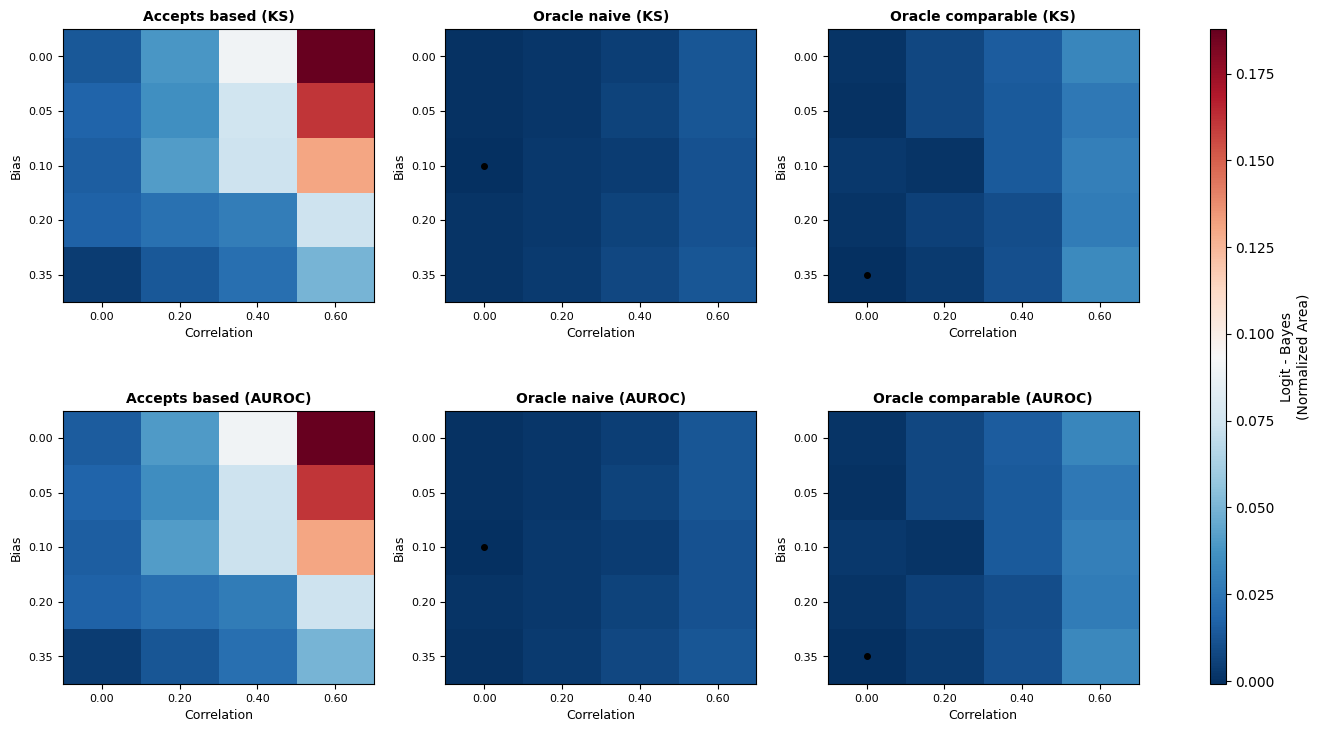

In [ ]:
# Extract biases and correlations from directory names
diff_types = ["diffs", "ma_diffs"]
# Construct all_diffs tensor
## [B, Co, E, M, Cl, D, N], [N]
all_diffs_new, sample_sizes, B, Co, E, M, D = construct_all_diffs_tensor(
    all_sim_objs,
    biases=grid_biases,
    corrs=grid_corrs,
    expectation_types=EXPECTATION_TYPES,
    metric_categories=METRIC_CATEGORIES,
    diff_types=diff_types,
    classifiers=["logit", "bayes"]
)

# Get areas
areas = get_areas(all_diffs_new, sample_sizes)

# Normalize areas
normed_areas = normalize_areas(areas, METRIC_CATEGORIES, sample_sizes)

# # Compute logit - bayes difference
logit_area_minus_bayes_normed = normed_areas[..., 0, :] - normed_areas[..., 1, :]


def custom_title_mapping(e_type: str, m_cat: str) -> str:
    e_type_map = {
        "acc_based" : "Accepts based",
        "oracle_naive" : "Oracle naive",
        "oracle_comparable" : "Oracle comparable"
    }
    m_cat_mapper = {
        "roc" : "AUROC",
        "ks" : "KS"
    }
    return f'{e_type_map[e_type]} ({m_cat_mapper[m_cat]})'

idx_diffs = 0

plot_heatmap_grid(
    data=logit_area_minus_bayes_normed[..., idx_diffs, :],
    metric_categories=METRIC_CATEGORIES,
    expectation_types=EXPECTATION_TYPES,
    biases=grid_biases,
    corrs=grid_corrs,
    cmap='RdBu_r',
    suptitle='',
    title_bold=True,
    cbar_label='Logit - Bayes\n(Normalized Area)',
    title_mapping=custom_title_mapping
)

In [28]:
EXPECTATION_TYPES

['acc_based', 'oracle_naive', 'oracle_comparable']

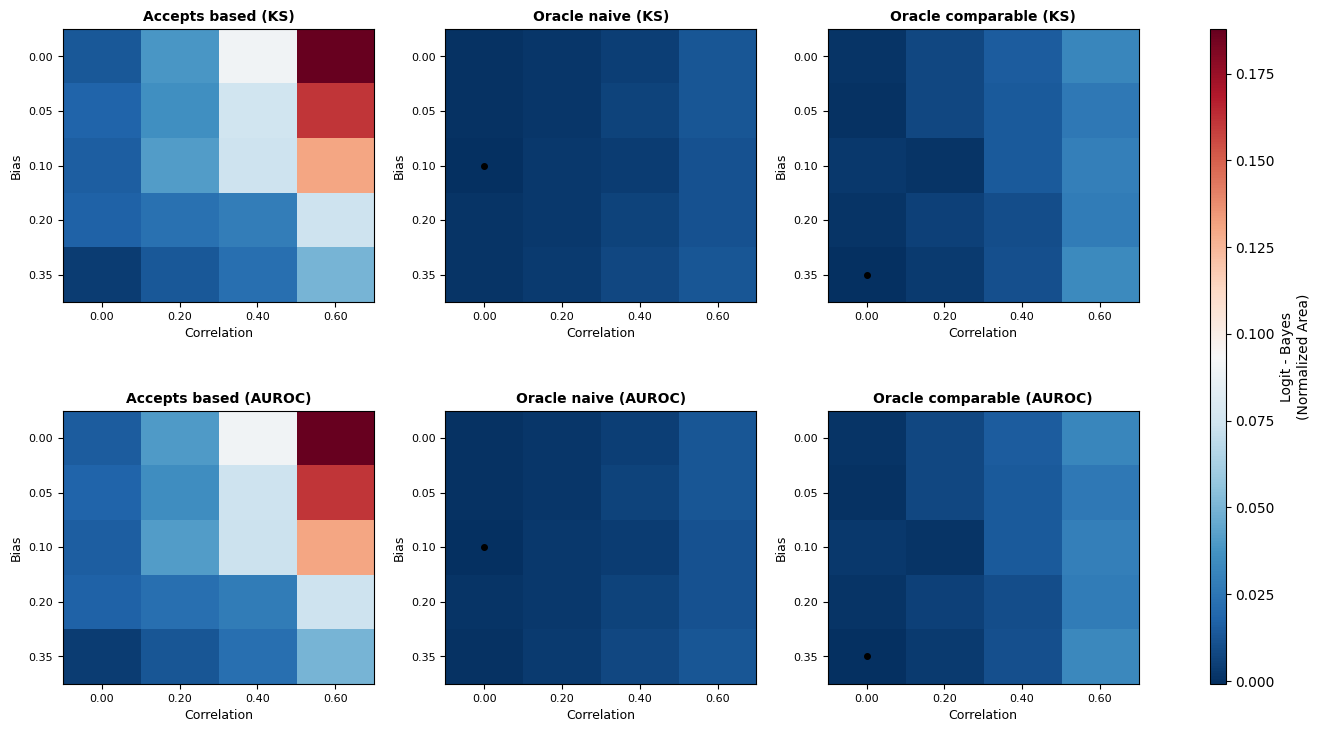

In [ ]:
def plot_heatmap_grid(
    data: torch.Tensor,
    metric_categories: list,
    expectation_types: list,
    biases: Dict[str, float],
    corrs: Dict[str, float],
    cmap: str = 'RdBu_r',
    suptitle: Optional[str] = None,
    title_bold: bool = True,
    cbar_label: str = 'Logit - Bayes\n(Normalized Area)',
    title_mapping: Optional[Callable[[str, str], str]] = None
) -> None:
    M_len = len(metric_categories)
    E_len = len(expectation_types)

    # Sort biases and corrs for consistent ordering
    sorted_bias_keys = sorted(biases.keys(), key=lambda x: biases[x])
    sorted_corr_keys = sorted(corrs.keys(), key=lambda x: corrs[x])
    
    bias_key_list = list(biases.keys())
    corr_key_list = list(corrs.keys())
    sorted_bias_idxs = [bias_key_list.index(k) for k in sorted_bias_keys]
    sorted_corr_idxs = [corr_key_list.index(k) for k in sorted_corr_keys]

    # Labels
    bias_labels = [f'{biases[k]:.2f}' for k in sorted_bias_keys]
    corr_labels = [f'{corrs[k]:.2f}' for k in sorted_corr_keys]

    fig = plt.figure(figsize=(5 * E_len, 4 * M_len + 0.5))
    gs = gridspec.GridSpec(
        M_len, E_len + 1,
        figure=fig,
        width_ratios=[1] * E_len + [0.05],
        wspace=0.3,
        hspace=0.4
    )
    
    im = None
    
    # Create heatmaps
    for m_idx, m_cat in enumerate(metric_categories):
        for e_idx, e_type in enumerate(expectation_types):
            ax = fig.add_subplot(gs[m_idx, e_idx])
            
            # Extract and reorder data
            raw_data = data[:, :, e_idx, m_idx, d_idx].numpy()
            heatmap_data = raw_data[np.ix_(sorted_bias_idxs, sorted_corr_idxs)]
            
            # Plot heatmap
            im = ax.imshow(heatmap_data, cmap=cmap, aspect='auto', vmin=v_min, vmax=v_max)
            
            # Add black dots to negative values
            for i in range(heatmap_data.shape[0]):
                for j in range(heatmap_data.shape[1]):
                    if heatmap_data[i, j] < 0:
                        ax.plot(j, i, 'k.', markersize=8)
            
            # Set title
            if title_mapping is not None:
                title = title_mapping(e_type, m_cat)
            else:
                title = f'{e_type}_{m_cat}'
            
            title_weight = 'bold' if title_bold else 'normal'
            ax.set_title(title, fontsize=10, fontweight=title_weight)
            
            # Set labels
            ax.set_xlabel('Correlation', fontsize=9)
            ax.set_ylabel('Bias', fontsize=9)
            
            # Set tick labels
            ax.set_xticks(range(len(sorted_corr_keys)))
            ax.set_xticklabels(corr_labels, fontsize=8)
            
            ax.set_yticks(range(len(sorted_bias_keys)))
            ax.set_yticklabels(bias_labels, fontsize=8)
    
    # Add colorbar in its own subplot
    cbar_ax = fig.add_subplot(gs[:, E_len])
    cbar = fig.colorbar(im, cax=cbar_ax)
    cbar.set_label(cbar_label, fontsize=10)
    
    # Add super title if provided
    if suptitle and len(suptitle) > 0:
        fig.suptitle(suptitle, fontsize=14, fontweight='bold', y=0.98)
    
    plt.show()

def plot_heatmap_grid(
    data: torch.Tensor,
    metric_categories: list,
    expectation_types: list,
    diff_types: list,
    biases: Dict[str, float],
    corrs: Dict[str, float],
    cmap: str = 'RdBu_r',
    suptitle: Optional[str] = None,
    title_bold: bool = True,
    cbar_label: str = 'Logit - Bayes\n(Normalized Area)',
    title_mapping: Optional[Callable[[str, str], str]] = None
) -> None:
    """
    Create and display a grid of heatmaps.
    
    Args:
        data: Tensor of shape [B, Co, E, M, D]
        metric_categories: List of metric categories
        expectation_types: List of expectation types
        diff_types: List of diff types
        biases: Dictionary of bias values
        corrs: Dictionary of correlation values
        cmap: Colormap to use
        suptitle: Super title for the figure (None or empty string = no suptitle)
        title_bold: Whether to make subplot titles bold
        cbar_label: Label for the colorbar
        title_mapping: Optional callable that takes (e_type, m_cat) and returns custom title
    """
    E_len = len(expectation_types)
    M_len = len(metric_categories)
    D_len = len(diff_types)
    
    # Sort biases and corrs for consistent ordering
    sorted_bias_keys = sorted(biases.keys(), key=lambda x: biases[x])
    sorted_corr_keys = sorted(corrs.keys(), key=lambda x: corrs[x])
    
    bias_key_list = list(biases.keys())
    corr_key_list = list(corrs.keys())
    sorted_bias_idxs = [bias_key_list.index(k) for k in sorted_bias_keys]
    sorted_corr_idxs = [corr_key_list.index(k) for k in sorted_corr_keys]
    
    # Find global min and max
    v_min = data.min().item()
    v_max = data.max().item()
    
    # Labels
    bias_labels = [f'{biases[k]:.2f}' for k in sorted_bias_keys]
    corr_labels = [f'{corrs[k]:.2f}' for k in sorted_corr_keys]
    
    # Create a figure for each diff_type
    for d_idx, diff_type in enumerate(diff_types):
        # Use GridSpec for proper layout with colorbar
        fig = plt.figure(figsize=(5 * E_len, 4 * M_len + 0.5))
        gs = gridspec.GridSpec(
            M_len, E_len + 1,
            figure=fig,
            width_ratios=[1] * E_len + [0.05],
            wspace=0.3,
            hspace=0.4
        )
        
        im = None
        
        # Create heatmaps
        for m_idx, m_cat in enumerate(metric_categories):
            for e_idx, e_type in enumerate(expectation_types):
                ax = fig.add_subplot(gs[m_idx, e_idx])
                
                # Extract and reorder data
                raw_data = data[:, :, e_idx, m_idx, d_idx].numpy()
                heatmap_data = raw_data[np.ix_(sorted_bias_idxs, sorted_corr_idxs)]
                
                # Plot heatmap
                im = ax.imshow(heatmap_data, cmap=cmap, aspect='auto', vmin=v_min, vmax=v_max)
                
                # Add black dots to negative values
                for i in range(heatmap_data.shape[0]):
                    for j in range(heatmap_data.shape[1]):
                        if heatmap_data[i, j] < 0:
                            ax.plot(j, i, 'k.', markersize=8)
                
                # Set title
                if title_mapping is not None:
                    title = title_mapping(e_type, m_cat)
                else:
                    title = f'{e_type}_{m_cat}'
                
                title_weight = 'bold' if title_bold else 'normal'
                ax.set_title(title, fontsize=10, fontweight=title_weight)
                
                # Set labels
                ax.set_xlabel('Correlation', fontsize=9)
                ax.set_ylabel('Bias', fontsize=9)
                
                # Set tick labels
                ax.set_xticks(range(len(sorted_corr_keys)))
                ax.set_xticklabels(corr_labels, fontsize=8)
                
                ax.set_yticks(range(len(sorted_bias_keys)))
                ax.set_yticklabels(bias_labels, fontsize=8)
        
        # Add colorbar in its own subplot
        cbar_ax = fig.add_subplot(gs[:, E_len])
        cbar = fig.colorbar(im, cax=cbar_ax)
        cbar.set_label(cbar_label, fontsize=10)
        
        # Add super title if provided
        if suptitle and len(suptitle) > 0:
            fig.suptitle(suptitle + f'\n(Diff Type: {diff_type})', fontsize=14, fontweight='bold', y=0.98)
        
        plt.show()

torch.Size([5, 4, 3, 2, 2])

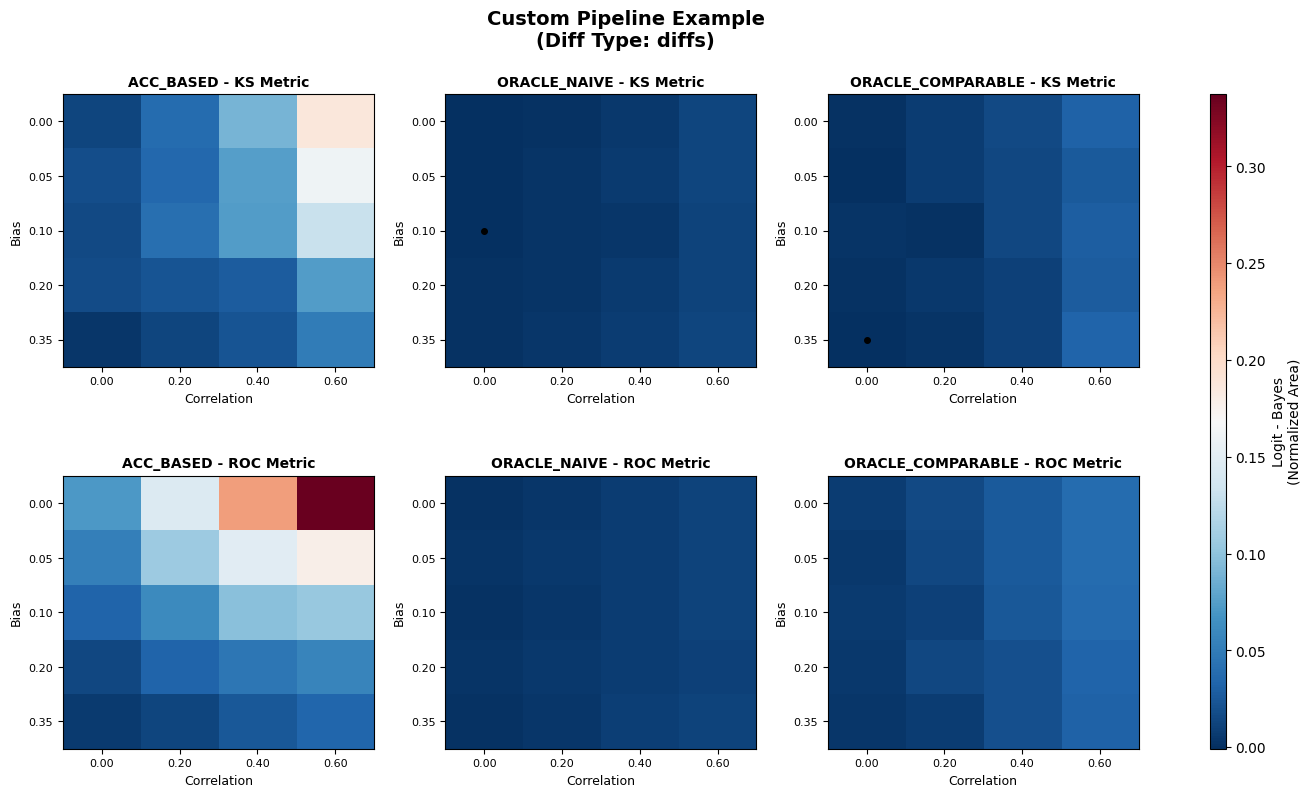

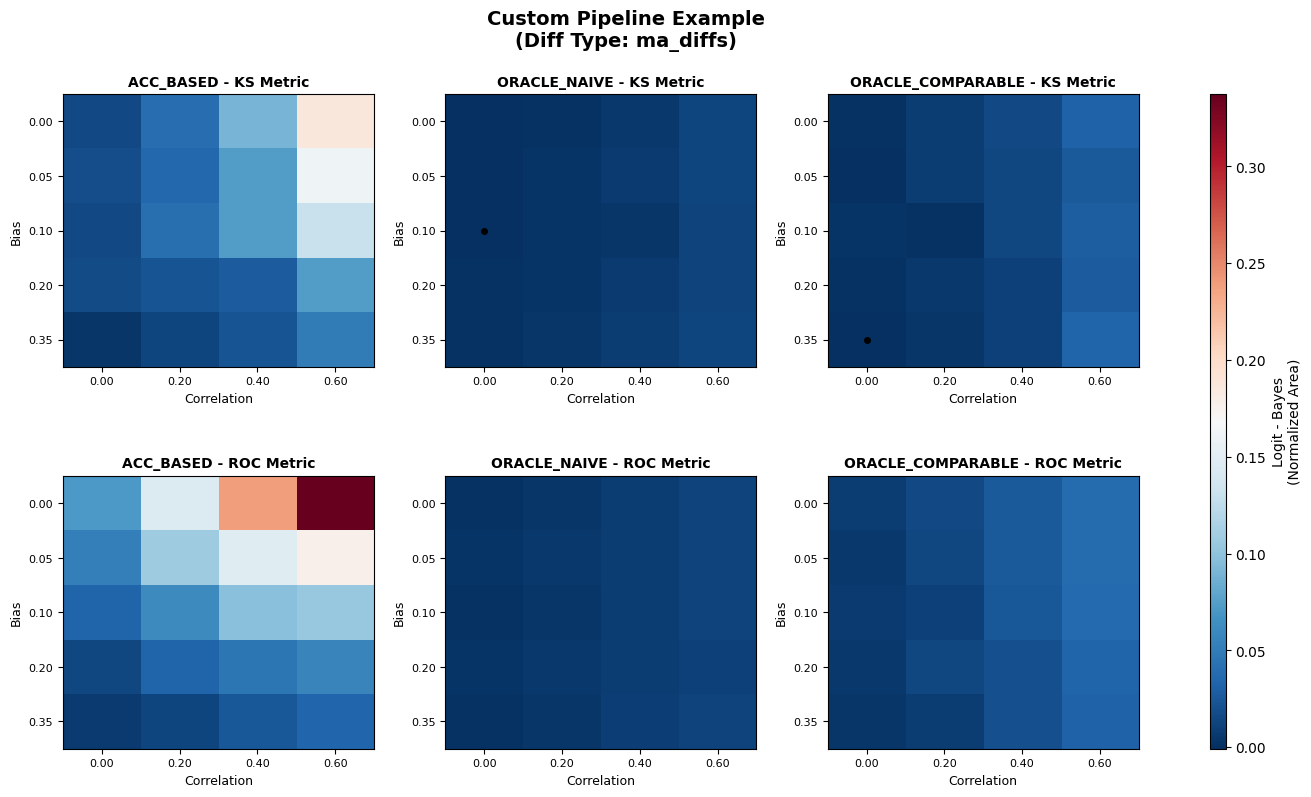

In [ ]:
plot_heatmap_grid(
    data=logit_area_minus_bayes_normed,
    metric_categories=METRIC_CATEGORIES,
    expectation_types=EXPECTATION_TYPES,
    diff_types=diff_types,
    biases=grid_biases,
    corrs=grid_corrs,
    cmap='RdBu_r',
    suptitle='Custom Pipeline Example',
    title_bold=True,
    cbar_label='Logit - Bayes\n(Normalized Area)',
    title_mapping=custom_title_mapping
)
# Need to fix this for both suptitle and loop behaviour

In [13]:
diff_types = ["diffs", "ma_diffs"]

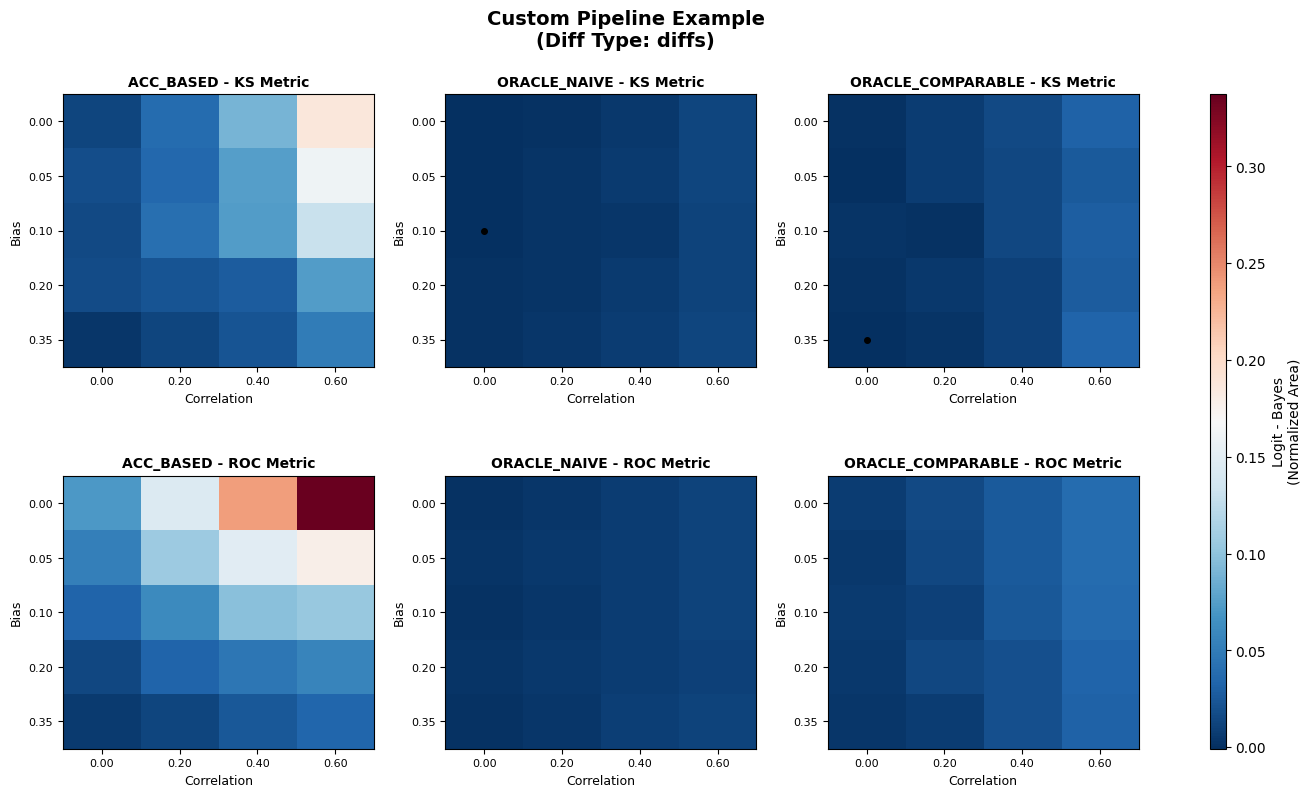

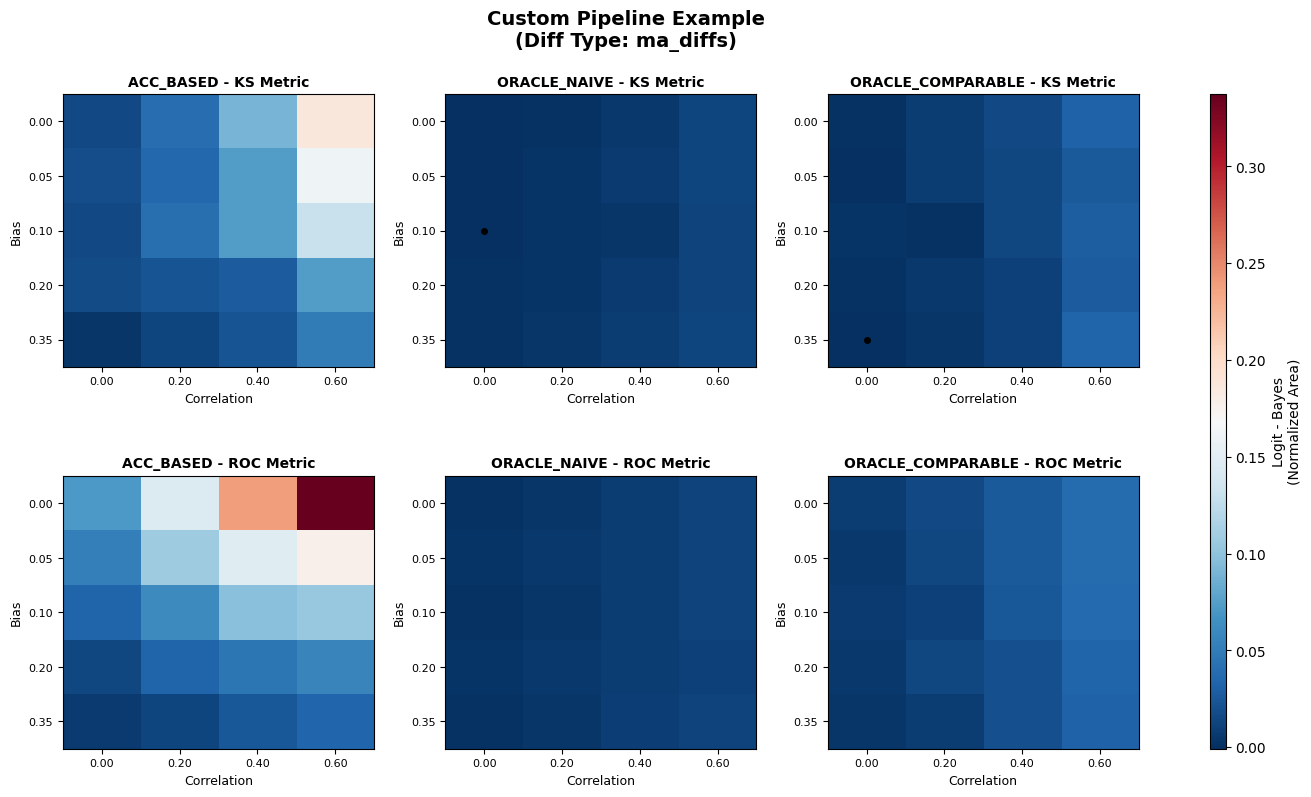

In [ ]:
areas = get_areas(all_diffs_new, sample_sizes)

# Normalize areas
normed_areas = normalize_areas(areas, METRIC_CATEGORIES, sample_sizes)

# # Compute logit - bayes difference
logit_area_minus_bayes_normed = normed_areas[..., 0, :] - normed_areas[..., 1, :]

# # Visualize with custom title mapping
def custom_title_mapping(e_type: str, m_cat: str) -> str:
    return f'{e_type.upper()} - {m_cat.upper()} Metric'

plot_heatmap_grid(
    data=logit_area_minus_bayes_normed,
    metric_categories=METRIC_CATEGORIES,
    expectation_types=EXPECTATION_TYPES,
    diff_types=diff_types,
    biases=grid_biases,
    corrs=grid_corrs,
    cmap='RdBu_r',
    suptitle='Custom Pipeline Example',
    title_bold=True,
    cbar_label='Logit - Bayes\n(Normalized Area)',
    title_mapping=custom_title_mapping
)

# Function Documentation

## Summary of Refactored Functions

### 1. `extract_biases_and_corrs_from_dirnames(dir_path)`
Extracts bias and correlation dictionaries from directory names in a given path.
- **Input:** Path to simulation directory
- **Output:** Tuple of (biases_dict, corrs_dict)

### 2. `construct_all_diffs_tensor(...)`
Constructs the all_diffs tensor by iterating over parameter combinations and extracting differences.
- **Input:** grid_path, biases, corrs, expectation_types, metric_categories, diff_types, sample_sizes
- **Output:** Tuple of (all_diffs_tensor, B, Co, E, M, D)
- **Shape:** [B, Co, E, M, Cl=2, D, N]

### 3. `get_areas(all_diffs, sample_sizes, metric_categories)`
Computes areas under curves using masked trapezoidal integration.
- **Input:** all_diffs tensor, sample sizes, metric categories
- **Output:** Areas tensor of shape [B, Co, E, M, Cl, D]

### 4. `normalize_areas(areas, metric_categories, sample_sizes)`
Normalizes areas by worst-case areas for each metric category.
- **Input:** areas tensor, metric categories, sample sizes
- **Output:** Normalized areas tensor of shape [B, Co, E, M, Cl, D]

### 5. `plot_heatmap_grid(...)`
Creates and displays a grid of heatmaps with customizable options.
- **Key Parameters:**
  - `suptitle`: Super title (None or empty string = no suptitle)
  - `title_bold`: Whether subplot titles are bold
  - `cbar_label`: Colorbar label
  - `title_mapping`: Optional callable to customize subplot titles as f(expectation_type, metric_category)
  - `cmap`: Colormap (default: 'RdBu_r')
- **Features:**
  - Uses GridSpec for proper layout (eliminates tight_layout warning)
  - Adds black dots to negative values
  - Creates separate figure for each diff_type
  - Uniform colorbar across all subplots